In [1]:
# ════════════════════════════════════════════════════════════════════════════
# DATALOADER SAM3 — VERSION FINALE
# ════════════════════════════════════════════════════════════════════════════

import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import xml.etree.ElementTree as ET
import torchvision.transforms.functional as TF
import random

os.environ['RAPIDS_NO_INITIALIZE']        = '1'
os.environ['CUPY_CACHE_SAVE_CUDA_SOURCE'] = '0'
os.environ['PYTORCH_ALLOC_CONF']          = 'expandable_segments:True'

CLASS_NAMES = [
    'voilier', 'yacht', 'jet_ski', 'bateau_peche',
    'navire_croisiere', 'navire_militaire', 'remorqueur', 'cargo'
]

PROMPTS_CLASSES = [
    "aerial view sailboat with mast on water",
    "aerial view luxury motor yacht on water",
    "aerial view jet ski personal watercraft on water",
    "aerial view fishing boat trawler commercial harbor on water",
    "aerial view large white cruise ship passenger vessel port",
    "aerial view grey military warship frigate navy vessel",
    "aerial view tugboat short wide red orange hull port",
    "aerial view cargo ship bulk carrier flat deck freight port",
]

IMAGE_SIZE  = 1008   # confirmé par les tests (vision_features 72x72)
MASK_SIZE   = 288    # aligné avec la sortie réelle du modèle (pred_masks 288x288)
DATASET_DIR = '/home/jupyter-p2m/dataset'


# ════════════════════════════════════════════════════════════════════════════
# PARSING XML CVAT
# ════════════════════════════════════════════════════════════════════════════

def parse_cvat_xml(xml_path):
    batch_dir = os.path.dirname(os.path.abspath(xml_path))
    tree      = ET.parse(xml_path)
    root      = tree.getroot()
    samples   = []

    for image_elem in root.findall('.//image'):
        img_name = image_elem.get('name')
        img_w    = int(image_elem.get('width'))
        img_h    = int(image_elem.get('height'))
        img_path = os.path.join(batch_dir, img_name)

        if not os.path.exists(img_path):
            continue

        objets = []
        for poly in image_elem.findall('polygon'):
            label = poly.get('label')
            if label not in CLASS_NAMES:
                continue
            coords = [
                tuple(map(float, p.split(',')))
                for p in poly.get('points').split(';')
            ]
            if len(coords) < 3:
                continue
            xs = [c[0] for c in coords]
            ys = [c[1] for c in coords]
            objets.append({
                'label'    : label,
                'class_idx': CLASS_NAMES.index(label),
                'coords'   : coords,
                'bbox'     : (min(xs), min(ys), max(xs), max(ys)),
            })

        if objets:
            samples.append({
                'image_path': img_path,
                'width'     : img_w,
                'height'    : img_h,
                'objets'    : objets,
            })
    return samples


def charger_split(split_dir):
    samples = []
    xmls    = sorted(glob.glob(
        f'{split_dir}/**/*_cvat.xml', recursive=True
    ))
    print(f"\nChargement {split_dir} ({len(xmls)} XML)")
    for xml in xmls:
        samples += parse_cvat_xml(xml)
    total_obj = sum(len(s['objets']) for s in samples)
    print(f"  → {len(samples)} images | {total_obj} objets")
    return samples


# ════════════════════════════════════════════════════════════════════════════
# DATASET
# ════════════════════════════════════════════════════════════════════════════

class SAM3SemanticDataset(Dataset):
    def __init__(self, samples, image_size=IMAGE_SIZE,
                 mask_size=MASK_SIZE, augment=False):
        self.image_size = image_size
        self.mask_size  = mask_size
        self.augment    = augment
        self.items      = samples

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item   = self.items[idx]
        orig_w = item['width']
        orig_h = item['height']

        # ── Image ─────────────────────────────────────────────────────
        image = Image.open(
            item['image_path']
        ).convert('RGB').resize(
            (self.image_size, self.image_size), Image.BILINEAR
        )

        # ── Augmentation ──────────────────────────────────────────────
        hf = self.augment and random.random() > 0.5
        vf = self.augment and random.random() > 0.5
        ag = random.choice([0, 90, 180, 270]) if self.augment else 0

        if hf: image = TF.hflip(image)
        if vf: image = TF.vflip(image)
        if ag: image = TF.rotate(image, ag)

        # float32 — le cast fp16 se fait sur GPU via autocast
        image_t = TF.normalize(
            TF.to_tensor(image),
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
        del image

        # ── GT masks ──────────────────────────────────────────────────
        gt_masks  = np.zeros(
            (len(CLASS_NAMES), self.mask_size, self.mask_size),
            dtype=np.float32
        )
        presence  = np.zeros(len(CLASS_NAMES), dtype=np.float32)
        nb_objets = np.zeros(len(CLASS_NAMES), dtype=np.int64)

        for obj in item['objets']:
            c = obj['class_idx']
            presence[c]   = 1.0
            nb_objets[c] += 1

            sx = self.mask_size / orig_w
            sy = self.mask_size / orig_h
            coords_scaled = [(x * sx, y * sy) for x, y in obj['coords']]

            mask_img = Image.new('L', (self.mask_size, self.mask_size), 0)
            ImageDraw.Draw(mask_img).polygon(coords_scaled, fill=255)
            mask_np  = (np.array(mask_img) > 127).astype(np.float32)
            del mask_img

            if hf or vf or ag:
                mp = Image.fromarray((mask_np * 255).astype(np.uint8))
                if hf: mp = TF.hflip(mp)
                if vf: mp = TF.vflip(mp)
                if ag: mp = TF.rotate(mp, ag)
                mask_np = (np.array(mp) > 127).astype(np.float32)
                del mp

            np.maximum(gt_masks[c], mask_np, out=gt_masks[c])
            del mask_np

        # image_path retiré du batch (strings incompatibles GPU / multi-worker)
        return {
            'image'    : image_t,                        # float32 [3,1008,1008]
            'gt_masks' : torch.from_numpy(gt_masks),     # float32 [8,288,288]
            'presence' : torch.from_numpy(presence),     # float32 [8]
            'nb_objets': torch.from_numpy(nb_objets),    # int64   [8]
        }


# ════════════════════════════════════════════════════════════════════════════
# CHARGEMENT
# ════════════════════════════════════════════════════════════════════════════

train_samples = charger_split(f'{DATASET_DIR}/train')
val_samples   = charger_split(f'{DATASET_DIR}/val')
test_samples  = charger_split(f'{DATASET_DIR}/test')

# num_workers=0 : évite les conflits CUDA dans les workers forkés
# pin_memory=False : inutile avec num_workers=0
train_loader = DataLoader(
    SAM3SemanticDataset(train_samples, IMAGE_SIZE, MASK_SIZE, augment=True),
    batch_size=1, shuffle=True, num_workers=0, pin_memory=False,
)
val_loader = DataLoader(
    SAM3SemanticDataset(val_samples, IMAGE_SIZE, MASK_SIZE, augment=False),
    batch_size=1, shuffle=False, num_workers=0, pin_memory=False,
)
test_loader = DataLoader(
    SAM3SemanticDataset(test_samples, IMAGE_SIZE, MASK_SIZE, augment=False),
    batch_size=1, shuffle=False, num_workers=0, pin_memory=False,
)

# ── Vérification ──────────────────────────────────────────────────────
b = next(iter(train_loader))
print(f"\nVérification batch :")
print(f"  image     : {b['image'].shape}    dtype={b['image'].dtype}")
print(f"  gt_masks  : {b['gt_masks'].shape} dtype={b['gt_masks'].dtype}")
print(f"  presence  : {b['presence']}       dtype={b['presence'].dtype}")
print(f"  nb_objets : {b['nb_objets']}      dtype={b['nb_objets'].dtype}")

assert b['gt_masks'].shape[-1] == MASK_SIZE, \
    f"MASK_SIZE attendu {MASK_SIZE}, got {b['gt_masks'].shape[-1]}"
assert b['image'].dtype == torch.float32, \
    f"Image doit être float32, got {b['image'].dtype}"

print(f"\n✅ Dataloader prêt !")
print(f"   Train : {len(train_samples)} images")
print(f"   Val   : {len(val_samples)} images")
print(f"   Test  : {len(test_samples)} images")
print(f"   IMAGE_SIZE={IMAGE_SIZE} | MASK_SIZE={MASK_SIZE}")


Chargement /home/jupyter-p2m/dataset/train (45 XML)
  → 895 images | 17095 objets

Chargement /home/jupyter-p2m/dataset/val (10 XML)
  → 196 images | 3412 objets

Chargement /home/jupyter-p2m/dataset/test (10 XML)
  → 195 images | 3624 objets

Vérification batch :
  image     : torch.Size([1, 3, 1008, 1008])    dtype=torch.float32
  gt_masks  : torch.Size([1, 8, 288, 288]) dtype=torch.float32
  presence  : tensor([[1., 1., 0., 0., 0., 0., 0., 1.]])       dtype=torch.float32
  nb_objets : tensor([[1, 2, 0, 0, 0, 0, 0, 1]])      dtype=torch.int64

✅ Dataloader prêt !
   Train : 895 images
   Val   : 196 images
   Test  : 195 images
   IMAGE_SIZE=1008 | MASK_SIZE=288


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FINE-TUNING SAM3SemanticModel — VERSION FINALE
#
# Prérequis : exécuter dataloader_sam3_final.py avant ce script
# Variables attendues dans le namespace :
#   CLASS_NAMES, PROMPTS_CLASSES, DATASET_DIR
#   train_loader, val_loader
#
# Corrections principales :
#   1. backbone.forward(captions=) au lieu de forward_image
#      → génère language_features nécessaires à forward_grounding
#   2. detach_features() coupe le graph du backbone avant forward_grounding
#      → évite de garder ~40 GB de graph inutile en mémoire
#   3. Backward immédiat par classe (pas d'accumulation des outputs)
#      → VRAM stable ~2.5 GB au lieu de OOM
#   4. Paramètres entraînables castés en float32
#      → GradScaler ne peut pas unscale des gradients fp16
#   5. Image castée en fp16 explicitement pour le backbone
#      → backbone est en fp16, image du dataloader est float32
#   6. torch.amp.GradScaler('cuda') nouvelle API (plus de FutureWarning)
# ════════════════════════════════════════════════════════════════════════════

import os
import glob
import re
import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.checkpoint import checkpoint
from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics.models.sam.sam3.geometry_encoders import Prompt
from tqdm import tqdm

os.chdir("/home/jupyter-p2m")
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

DEVICE     = 'cuda'
CHECKPOINT = '/home/jupyter-p2m/checkpoints2'
os.makedirs(CHECKPOINT, exist_ok=True)

print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


# ════════════════════════════════════════════════════════════════════════════
# CHARGEMENT DU MODÈLE
# ════════════════════════════════════════════════════════════════════════════

overrides = dict(
    conf  = 0.25,
    task  = "segment",
    mode  = "predict",
    model = "/home/jupyter-p2m/sam3.pt",
    save  = False,
    imgsz = 1008,
    half  = True,   # backbone en fp16 pour économiser la VRAM
)
predictor = SAM3SemanticPredictor(overrides=overrides)
dummy_img  = next(glob.iglob(f'{DATASET_DIR}/train/**/*.png', recursive=True))
predictor.set_image(dummy_img)
sam = predictor.model.to(DEVICE)
sam.set_classes(text=PROMPTS_CLASSES)

fshape = predictor.features['vision_features'].shape
print(f"✓ vision_features : {fshape}")
assert fshape[-1] == 72, "Erreur : imgsz doit être 1008"

# ── Étape 1 : geler le backbone ───────────────────────────────────────
for name, param in sam.named_parameters():
    param.requires_grad = 'backbone' not in name

# ── Étape 2 : caster les params entraînables en float32 ───────────────
# CRITIQUE : le modèle est chargé en fp16 (half=True)
# GradScaler.unscale_() refuse les gradients fp16
# Solution : backbone reste fp16 (gelé), couches entraînables → float32
for name, param in sam.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()

# Vérification
fp16_trainable = [
    n for n, p in sam.named_parameters()
    if p.requires_grad and p.dtype == torch.float16
]
fp32_trainable = [
    n for n, p in sam.named_parameters()
    if p.requires_grad and p.dtype == torch.float32
]
assert len(fp16_trainable) == 0, \
    f"Encore {len(fp16_trainable)} params entraînables en fp16 !"

trainable = sum(p.numel() for p in sam.parameters() if p.requires_grad)
total     = sum(p.numel() for p in sam.parameters())
print(f"Entraînables (float32) : {len(fp32_trainable)} tenseurs | "
      f"{trainable:,} params ({100*trainable/total:.1f}%)")
print(f"Backbone (float16)     : gelé")
print(f"VRAM après chargement  : {torch.cuda.memory_allocated(0)/1e9:.2f} GB")


# ════════════════════════════════════════════════════════════════════════════
# UTILITAIRES
# ════════════════════════════════════════════════════════════════════════════

def detach_features(feats: dict) -> dict:
    """
    Détache toutes les features du graph de calcul.
    CRITIQUE : sans ça PyTorch garde le graph du backbone (~40 GB) en mémoire
    pendant tout le forward_grounding → OOM garanti.
    """
    out = {}
    for k, v in feats.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.detach().requires_grad_(False)
        elif isinstance(v, list):
            out[k] = [
                vi.detach().requires_grad_(False)
                if isinstance(vi, torch.Tensor) else vi
                for vi in v
            ]
        else:
            out[k] = v
    return out


def run_one_class(sam, feats: dict, class_idx: int) -> dict:
    """
    Forward SAM3 pour une seule classe avec gradient checkpointing.
    Le checkpointing évite de garder toutes les activations en mémoire :
    elles sont recalculées pendant le backward → VRAM divisée par ~4.
    """
    def _inner(c_idx_tensor):
        c = int(c_idx_tensor.item())
        geo = Prompt(
            box_embeddings=torch.zeros(0, 1, 4, device=DEVICE),
            box_mask=torch.zeros(1, 0, device=DEVICE, dtype=torch.bool),
        )
        return sam.forward_grounding(
            backbone_out     = feats,
            text_ids         = torch.tensor([c], device=DEVICE,
                                            dtype=torch.long),
            geometric_prompt = geo,
        )

    c_tensor = torch.tensor(class_idx, device=DEVICE, dtype=torch.long)
    return checkpoint(_inner, c_tensor, use_reentrant=False)


# ════════════════════════════════════════════════════════════════════════════
# LOSS PAR CLASSE
# ════════════════════════════════════════════════════════════════════════════

def loss_une_classe(out_c: dict,
                    gt_mask_c: torch.Tensor,
                    presence_c: torch.Tensor) -> torch.Tensor:
    """
    Loss pour une seule classe.

    Args:
        out_c       : output forward_grounding pour 1 classe
                        pred_masks         [1, 200, H, H]
                        presence_logit_dec [1, 1]
        gt_mask_c   : masque GT [288, 288]
        presence_c  : scalaire 0.0 / 1.0

    Returns:
        loss scalaire normalisée sur nb_classes
    """
    pred_m = out_c['pred_masks']           # [1, 200, H, H]
    pres_l = out_c['presence_logit_dec']   # [1, 1]
    nc     = len(CLASS_NAMES)

    # gt déjà à 288x288 (MASK_SIZE=288 dans le dataloader)
    # Si H != 288 par sécurité on interpolate
    H = pred_m.shape[-1]
    if gt_mask_c.shape[-1] != H:
        gt_c = F.interpolate(
            gt_mask_c.unsqueeze(0).unsqueeze(0).float(),
            size=(H, H), mode='bilinear', align_corners=False
        ).squeeze(0).squeeze(0)
    else:
        gt_c = gt_mask_c.float()

    # ── Présence loss ─────────────────────────────────────────────────
    pres_loss = F.binary_cross_entropy_with_logits(
        pres_l[0, 0].unsqueeze(0),
        presence_c.unsqueeze(0)
    )

    # ── Segmentation loss ─────────────────────────────────────────────
    if presence_c.item() < 0.5:
        # Classe absente → pénaliser légèrement les faux positifs
        seg_loss = F.binary_cross_entropy_with_logits(
            pred_m[0],
            torch.zeros_like(pred_m[0])
        ) * 0.05
    else:
        # Classe présente → meilleure query (max IoU pixel)
        with torch.no_grad():
            p_bin  = (torch.sigmoid(pred_m[0]) > 0.5).float()  # [200,H,H]
            gt_exp = gt_c.unsqueeze(0)                          # [1,H,H]
            inter  = (p_bin * gt_exp).sum(dim=(-2, -1))
            union  = (p_bin + gt_exp).clamp(0, 1).sum(dim=(-2, -1))
            best_q = (inter / (union + 1e-6)).argmax()

        best_pred = pred_m[0, best_q]   # [H, H]

        bce  = F.binary_cross_entropy_with_logits(best_pred, gt_c)

        p_s     = torch.sigmoid(best_pred)
        inter_d = (p_s * gt_c).sum()
        union_d = p_s.sum() + gt_c.sum()
        dice    = 1 - (2 * inter_d + 1e-6) / (union_d + 1e-6)

        seg_loss = 0.5 * bce + 0.5 * dice

    # seg 70% / présence 30%, normalisé sur nb_classes
    return (0.7 * seg_loss + 0.3 * pres_loss) / nc


# ════════════════════════════════════════════════════════════════════════════
# MÉTRIQUES
# ════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def metriques_une_classe(out_c: dict,
                          gt_mask_c: torch.Tensor,
                          presence_c: torch.Tensor,
                          seuil: float = 0.5):
    """Retourne (iou, correct) pour une classe, ou (None, None) si absente."""
    if presence_c.item() < 0.5:
        return None, None

    pred_m = out_c['pred_masks']   # [1, 200, H, H]
    H      = pred_m.shape[-1]

    if gt_mask_c.shape[-1] != H:
        gt_c = F.interpolate(
            gt_mask_c.unsqueeze(0).unsqueeze(0).float(),
            size=(H, H), mode='bilinear', align_corners=False
        ).squeeze(0).squeeze(0)
    else:
        gt_c = gt_mask_c.float()

    p_bin  = (torch.sigmoid(pred_m[0]) > 0.5).float()
    gt_exp = gt_c.unsqueeze(0)
    inter  = (p_bin * gt_exp).sum(dim=(-2, -1))
    union  = (p_bin + gt_exp).clamp(0, 1).sum(dim=(-2, -1))
    best   = (inter / (union + 1e-6)).max().item()

    return best, float(best >= seuil)


# ════════════════════════════════════════════════════════════════════════════
# TRAIN / VALIDATE
# ════════════════════════════════════════════════════════════════════════════

def train_one_epoch(sam, loader, optimizer, scaler, epoch):
    sam.train()
    sam.backbone.eval()   # backbone toujours en eval (gelé)

    total_loss = total_iou = total_acc = n_batch = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [TRAIN]')
    for batch in pbar:
        img      = batch['image'].to(DEVICE)      # float32 [1,3,1008,1008]
        gt_masks = batch['gt_masks'].to(DEVICE)   # float32 [1,8,288,288]
        presence = batch['presence'].to(DEVICE)   # float32 [1,8]

        optimizer.zero_grad()

        # ── Backbone : image + texte (gelé, no_grad) ──────────────────
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                # Cast explicite fp16 pour le backbone (qui est en fp16)
                img_fp16      = img[0].unsqueeze(0).half()
                full_features = sam.backbone(img_fp16,
                                             captions=PROMPTS_CLASSES)
                del img_fp16

        # CRITIQUE : détacher pour couper le graph du backbone
        feats = detach_features(full_features)
        del full_features
        torch.cuda.empty_cache()

        # ── Forward + loss + backward classe par classe ────────────────
        # On ne garde JAMAIS plus d'1 classe en mémoire à la fois
        # Les gradients s'accumulent dans .grad des paramètres
        batch_loss = 0.0
        ious       = []
        accs       = []
        oom        = False

        for c in range(len(CLASS_NAMES)):
            torch.cuda.empty_cache()
            try:
                with torch.amp.autocast('cuda'):
                    out_c  = run_one_class(sam, feats, c)
                    loss_c = loss_une_classe(
                        out_c,
                        gt_masks[0, c],   # [288, 288]
                        presence[0, c],   # scalaire
                    )

                # Backward IMMÉDIAT — libère le graph tout de suite
                scaler.scale(loss_c).backward()
                batch_loss += loss_c.item() * len(CLASS_NAMES)

                iou, acc = metriques_une_classe(
                    out_c, gt_masks[0, c], presence[0, c]
                )
                if iou is not None:
                    ious.append(iou)
                    accs.append(acc)

                del out_c, loss_c
                torch.cuda.empty_cache()

            except torch.cuda.OutOfMemoryError:
                print(f"\n⚠️  OOM classe {c} epoch {epoch} — skip batch")
                oom = True
                torch.cuda.empty_cache()
                break

        del feats
        torch.cuda.empty_cache()

        if oom:
            optimizer.zero_grad()
            continue

        # ── Optimizer step ────────────────────────────────────────────
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(sam.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        mean_iou = float(np.mean(ious)) if ious else 0.0
        mean_acc = float(np.mean(accs)) if accs else 0.0
        total_loss += batch_loss
        total_iou  += mean_iou
        total_acc  += mean_acc
        n_batch    += 1

        pbar.set_postfix({
            'loss': f'{batch_loss:.4f}',
            'iou' : f'{mean_iou:.4f}',
            'acc' : f'{mean_acc:.4f}',
        })

    if n_batch == 0:
        return 0.0, 0.0, 0.0
    return total_loss/n_batch, total_iou/n_batch, total_acc/n_batch


@torch.no_grad()
def validate(sam, loader, epoch):
    sam.eval()

    total_loss = total_iou = total_acc = n_batch = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [VAL]  ')
    for batch in pbar:
        img      = batch['image'].to(DEVICE)
        gt_masks = batch['gt_masks'].to(DEVICE)
        presence = batch['presence'].to(DEVICE)

        with torch.amp.autocast('cuda'):
            img_fp16      = img[0].unsqueeze(0).half()
            full_features = sam.backbone(img_fp16, captions=PROMPTS_CLASSES)
            del img_fp16

        feats = detach_features(full_features)
        del full_features
        torch.cuda.empty_cache()

        batch_loss = 0.0
        ious       = []
        accs       = []

        for c in range(len(CLASS_NAMES)):
            torch.cuda.empty_cache()
            try:
                with torch.amp.autocast('cuda'):
                    out_c  = run_one_class(sam, feats, c)
                    loss_c = loss_une_classe(
                        out_c, gt_masks[0, c], presence[0, c]
                    )
                batch_loss += loss_c.item() * len(CLASS_NAMES)

                iou, acc = metriques_une_classe(
                    out_c, gt_masks[0, c], presence[0, c]
                )
                if iou is not None:
                    ious.append(iou)
                    accs.append(acc)

                del out_c, loss_c
                torch.cuda.empty_cache()

            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()
                continue

        del feats
        torch.cuda.empty_cache()

        mean_iou = float(np.mean(ious)) if ious else 0.0
        mean_acc = float(np.mean(accs)) if accs else 0.0
        total_loss += batch_loss
        total_iou  += mean_iou
        total_acc  += mean_acc
        n_batch    += 1

        pbar.set_postfix({
            'loss': f'{batch_loss:.4f}',
            'iou' : f'{mean_iou:.4f}',
            'acc' : f'{mean_acc:.4f}',
        })

    if n_batch == 0:
        return 0.0, 0.0, 0.0
    return total_loss/n_batch, total_iou/n_batch, total_acc/n_batch


# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

EPOCHS     = 60
SAVE_EVERY = 2
patience   = 10

# Nouvelle API torch.amp (plus de FutureWarning)
scaler    = torch.amp.GradScaler('cuda')
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, sam.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)


# ════════════════════════════════════════════════════════════════════════════
# REPRISE DEPUIS CHECKPOINT
# ════════════════════════════════════════════════════════════════════════════

def dernier_ckpt(d):
    tous = []
    for pattern in [f'{d}/checkpoint_arret*.pt',
                    f'{d}/checkpoint_early*.pt',
                    f'{d}/checkpoint_epoch*.pt']:
        tous += glob.glob(pattern)
    if not tous:
        return None
    def ep(x):
        m = re.search(r'epoch(\d+)', os.path.basename(x))
        return int(m.group(1)) if m else 0
    return sorted(tous, key=ep)[-1]


ckpt_path = dernier_ckpt(CHECKPOINT)
if ckpt_path:
    print(f"\n✓ Reprise : {os.path.basename(ckpt_path)}")
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    sam.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    if 'scaler_state' in ckpt:
        scaler.load_state_dict(ckpt['scaler_state'])
    start_epoch = ckpt['epoch'] + 1
    best_iou    = ckpt['best_iou']
    history     = ckpt.get('history', [])
    print(f"  epoch={start_epoch} | best_iou={best_iou:.4f}")
else:
    print("\nDémarrage epoch 1")
    start_epoch = 1
    best_iou    = 0.0
    history     = []

sam.set_classes(text=PROMPTS_CLASSES)

print(f"\n{'='*55}")
print(f"  Fine-tuning SAM3SemanticModel — VERSION FINALE")
print(f"  Stratégie  : backward immédiat par classe")
print(f"  VRAM stable : ~2.5 GB")
print(f"  Checkpoints → {CHECKPOINT}")
print(f"  Epochs {start_epoch}→{EPOCHS} | patience={patience}")
print(f"{'='*55}\n")


# ════════════════════════════════════════════════════════════════════════════
# BOUCLE PRINCIPALE
# ════════════════════════════════════════════════════════════════════════════

epochs_no_improv = 0

for epoch in range(start_epoch, EPOCHS + 1):

    # ── Arrêt propre via fichier STOP_TRAINING ────────────────────────
    if os.path.exists('/home/jupyter-p2m/STOP_TRAINING'):
        os.remove('/home/jupyter-p2m/STOP_TRAINING')
        torch.save({
            'epoch'          : epoch,
            'model_state'    : sam.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'scaler_state'   : scaler.state_dict(),
            'best_iou'       : best_iou,
            'history'        : history,
        }, f'{CHECKPOINT}/checkpoint_arret_epoch{epoch:02d}.pt')
        print(f"  Arrêt propre epoch {epoch}")
        break

    # ── Train ─────────────────────────────────────────────────────────
    tl, ti, ta = train_one_epoch(sam, train_loader, optimizer,
                                  scaler, epoch)

    # ── Validate ──────────────────────────────────────────────────────
    vl, vi, va = validate(sam, val_loader, epoch)
    scheduler.step()

    vram_used = torch.cuda.memory_allocated(0) / 1e9
    print(f"\nEpoch {epoch:02d}/{EPOCHS}")
    print(f"  Train → loss:{tl:.4f}  IoU:{ti:.4f}  Acc:{ta:.4f}")
    print(f"  Val   → loss:{vl:.4f}  IoU:{vi:.4f}  Acc:{va:.4f}")
    print(f"  LR    → {optimizer.param_groups[0]['lr']:.2e}")
    print(f"  VRAM  → {vram_used:.2f} GB")

    history.append({
        'epoch'     : epoch,
        'train_loss': tl, 'train_iou': ti, 'train_acc': ta,
        'val_loss'  : vl, 'val_iou'  : vi, 'val_acc'  : va,
    })

    # ── Meilleur modèle ───────────────────────────────────────────────
    if vi > best_iou:
        best_iou         = vi
        epochs_no_improv = 0
        torch.save(
            sam.state_dict(),
            f'{CHECKPOINT}/sam3_semantic_best.pt'
        )
        print(f"  ✓ Meilleur modèle sauvegardé (IoU={best_iou:.4f})")
    else:
        epochs_no_improv += 1
        print(f"  Pas d'amélioration : {epochs_no_improv}/{patience}")

    # ── Early stopping ────────────────────────────────────────────────
    if epochs_no_improv >= patience:
        print(f"  Early stopping epoch {epoch}")
        torch.save({
            'epoch'          : epoch,
            'model_state'    : sam.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'scaler_state'   : scaler.state_dict(),
            'best_iou'       : best_iou,
            'history'        : history,
        }, f'{CHECKPOINT}/checkpoint_early_stop_epoch{epoch:02d}.pt')
        break

    # ── Checkpoint périodique ─────────────────────────────────────────
    if epoch % SAVE_EVERY == 0:
        torch.save({
            'epoch'          : epoch,
            'model_state'    : sam.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'scaler_state'   : scaler.state_dict(),
            'best_iou'       : best_iou,
            'history'        : history,
        }, f'{CHECKPOINT}/checkpoint_epoch{epoch:02d}.pt')
        print(f"  ✓ Checkpoint epoch {epoch}")

        # Garder seulement les 3 derniers checkpoints périodiques
        ckpts = sorted(glob.glob(f'{CHECKPOINT}/checkpoint_epoch*.pt'))
        for old in ckpts[:-3]:
            os.remove(old)

print(f"\n  Terminé ! Best IoU val : {best_iou:.4f}")

GPU  : NVIDIA RTX 6000 Ada Generation
VRAM : 50.9 GB
Ultralytics 8.4.21 🚀 Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48500MiB)
✓ vision_features : torch.Size([1, 256, 72, 72])
Entraînables (float32) : 391 tenseurs | 32,612,918 params (3.8%)
Backbone (float16)     : gelé
VRAM après chargement  : 6.58 GB

✓ Reprise : checkpoint_epoch16.pt
  epoch=17 | best_iou=0.6479

  Fine-tuning SAM3SemanticModel — VERSION FINALE
  Stratégie  : backward immédiat par classe
  VRAM stable : ~2.5 GB
  Checkpoints → /home/jupyter-p2m/checkpoints2
  Epochs 17→60 | patience=10



Epoch 17 [VAL]  : 100%|██████████| 196/196 [02:41<00:00,  1.22it/s, loss=0.1785, iou=0.5713, acc=1.0000]



Epoch 17/60
  Train → loss:0.7148  IoU:0.7068  Acc:0.7833
  Val   → loss:1.1653  IoU:0.5745  Acc:0.6118
  LR    → 8.17e-05
  VRAM  → 6.73 GB
  Pas d'amélioration : 1/10


Epoch 18 [TRAIN]:   0%|          | 0/895 [00:00<?, ?it/s]

Ultralytics 8.4.21 🚀 Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48500MiB)
✅ Poids fine-tunés chargés

📊 TEST SET...


Éval [TEST]: 100%|██████████| 195/195 [02:33<00:00,  1.27it/s]



📊 VAL SET...


Éval [VAL]: 100%|██████████| 196/196 [02:35<00:00,  1.26it/s]



════════════════════════════════════════════════════════════════════════════════════════════════════
  TEST SET
════════════════════════════════════════════════════════════════════════════════════════════════════
  Classe                 Precision    Recall        F1  Accuracy   IoU seg  │     TP    FP    FN    TN
  --------------------------------------------------------------------------------------------------
  voilier                    0.750     0.500     0.600     0.918     0.480  │     12     4    12   167
  yacht                      0.853     0.877     0.865     0.897     0.567  │     64    11     9   111
  jet_ski                    0.000     0.000     0.000     0.949     0.000  │      0     0    10   185
  bateau_peche               0.757     0.602     0.671     0.733     0.355  │     53    17    35    90
  navire_croisiere           0.788     0.703     0.743     0.908     0.792  │     26     7    11   151
  navire_militaire           0.824     0.651     0.727     0.892   

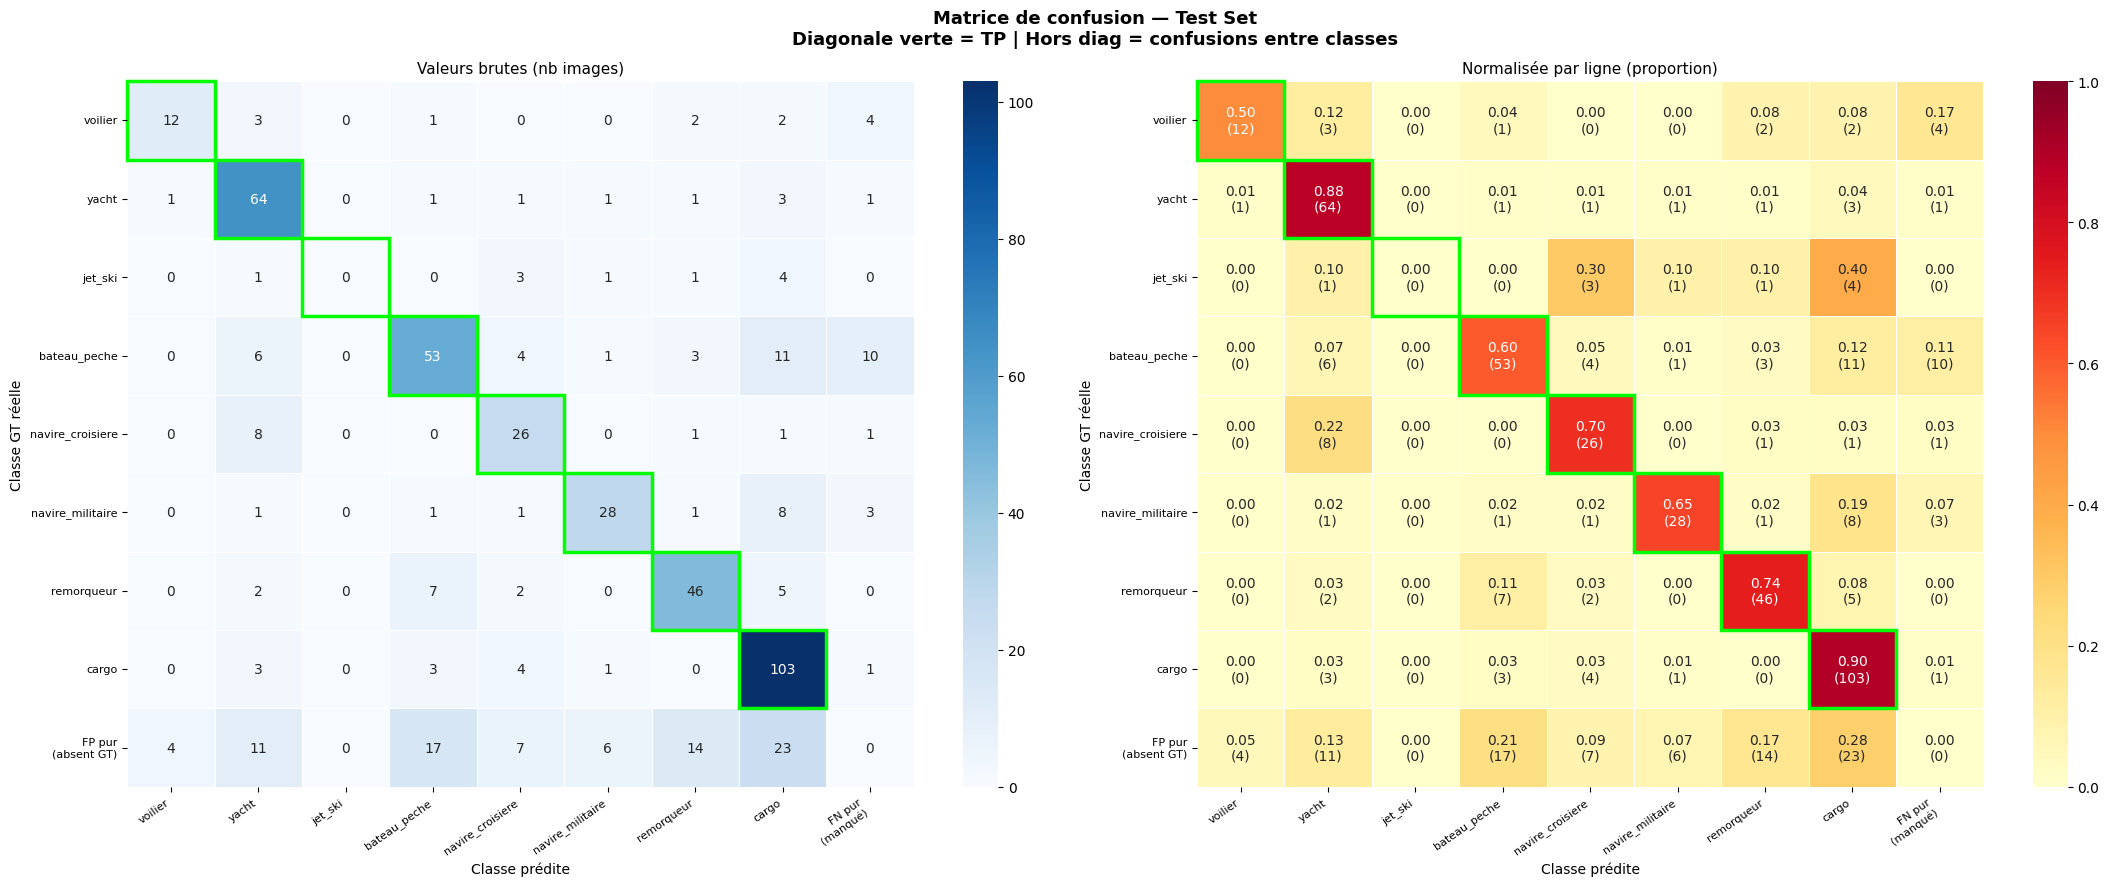

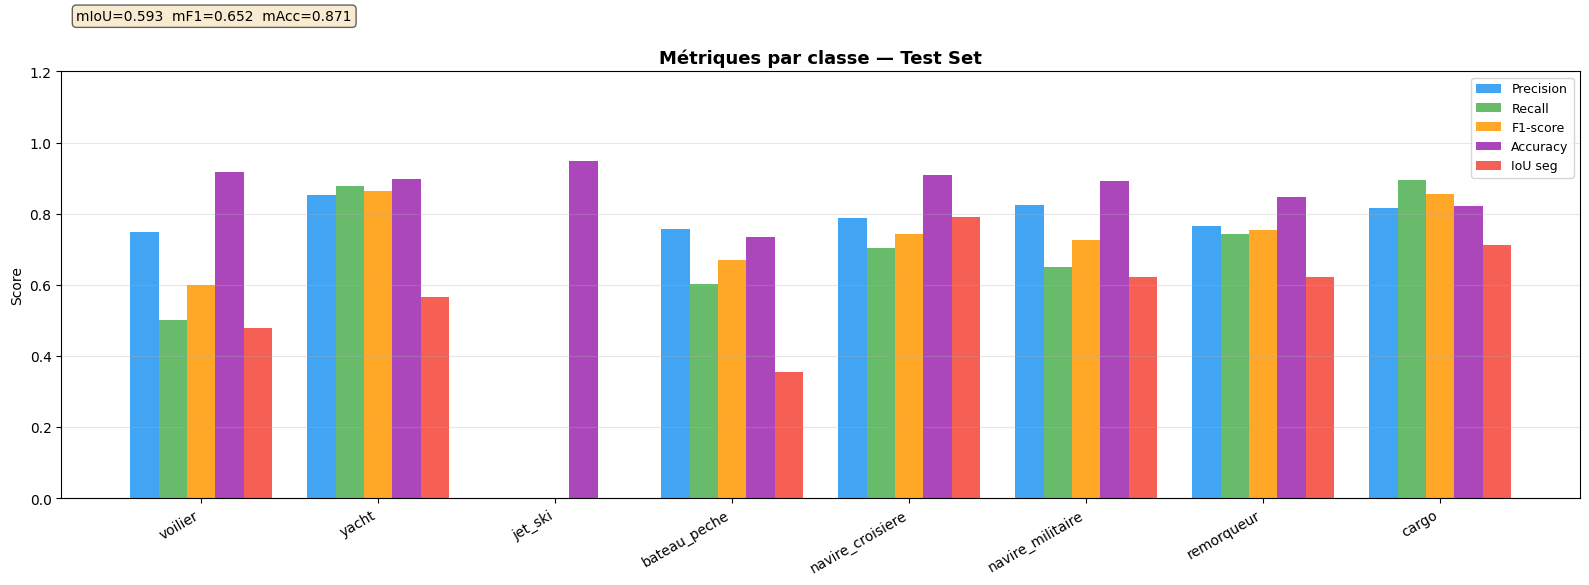

✓ 5 dernières epochs depuis checkpoint_periodique_epoch32.pt


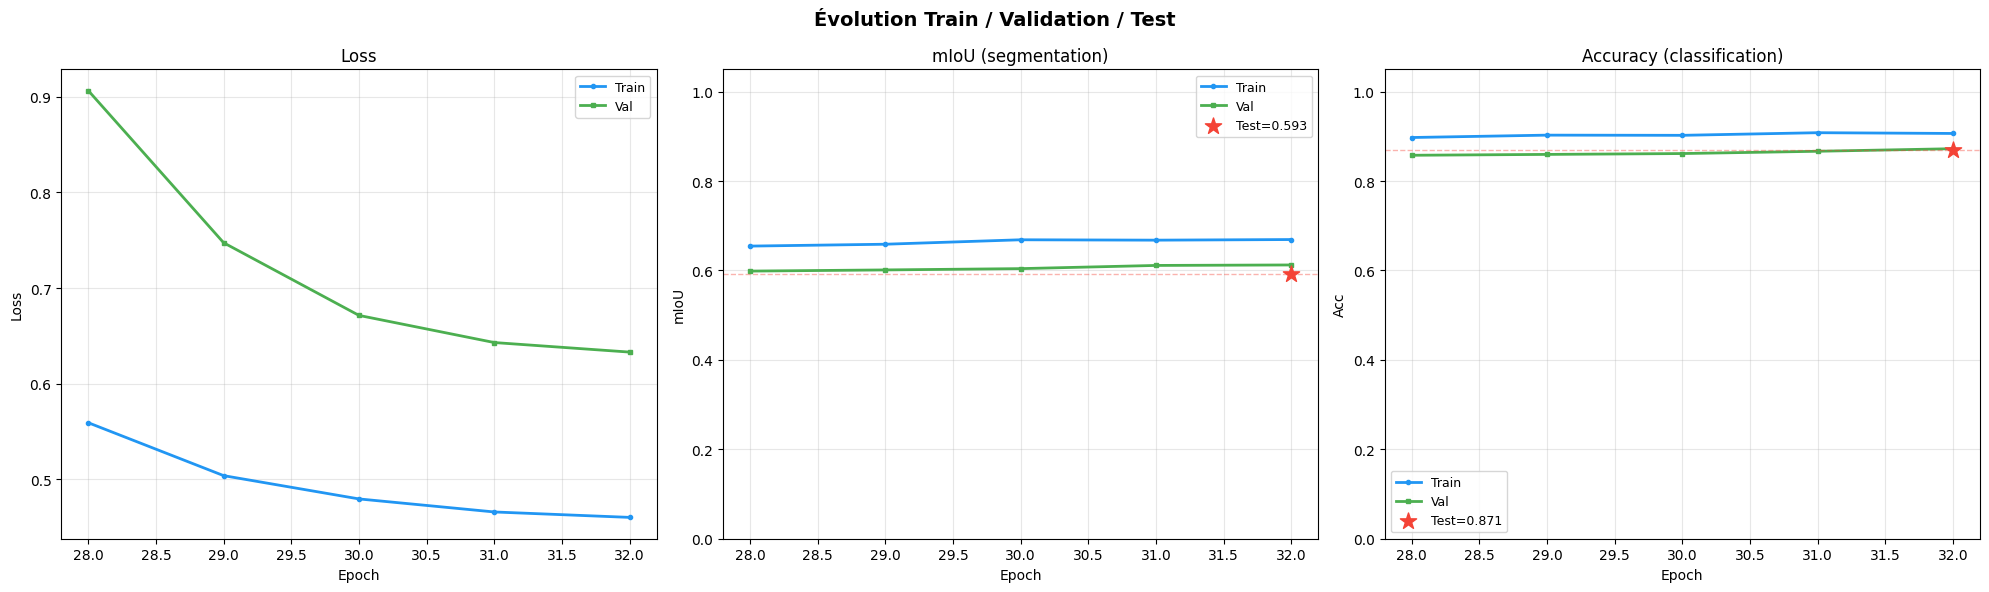


═══════════════════════════════════════════════════════
  RÉSUMÉ TEST SET
  mIoU       : 0.5932
  mPrecision : 0.6945
  mRecall    : 0.6213
  mF1        : 0.6518
  mAccuracy  : 0.8705
═══════════════════════════════════════════════════════

📁 /home/jupyter-p2m/evaluation/


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# ÉVALUATION SAM3 — VERSION FINALE CORRIGÉE
# ════════════════════════════════════════════════════════════════════════════

import os, glob, re, torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

os.chdir("/home/jupyter-p2m")
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

DEVICE         = 'cuda'
CHECKPOINT_DIR = '/home/jupyter-p2m/checkpoints2'
BEST_MODEL     = f'{CHECKPOINT_DIR}/sam3_semantic_best.pt'
SEUIL_PRESENCE = 0.5
NC             = len(CLASS_NAMES)
OUTPUT_DIR     = '/home/jupyter-p2m/evaluation'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ════════════════════════════════════════════════════════════════════════════
# CHARGEMENT MODÈLE
# ════════════════════════════════════════════════════════════════════════════

from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics.models.sam.sam3.geometry_encoders import Prompt

overrides = dict(conf=0.25, task="segment", mode="predict",
                 model="/home/jupyter-p2m/sam3.pt",
                 save=False, imgsz=1008, half=True)
predictor = SAM3SemanticPredictor(overrides=overrides)
dummy_img = next(glob.iglob(f'{DATASET_DIR}/train/**/*.png', recursive=True))
predictor.set_image(dummy_img)
sam = predictor.model.to(DEVICE)

if os.path.exists(BEST_MODEL):
    sam.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))
    print(f"✅ Poids fine-tunés chargés")
else:
    print("⚠️  Modèle de base")

sam.set_classes(text=PROMPTS_CLASSES)
sam.eval()


# ════════════════════════════════════════════════════════════════════════════
# UTILITAIRES
# ════════════════════════════════════════════════════════════════════════════

def detach_features(feats):
    out = {}
    for k, v in feats.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.detach().requires_grad_(False)
        elif isinstance(v, list):
            out[k] = [vi.detach().requires_grad_(False)
                      if isinstance(vi, torch.Tensor) else vi for vi in v]
        else:
            out[k] = v
    return out

@torch.no_grad()
def run_one_class_eval(sam, feats, c):
    geo = Prompt(
        box_embeddings=torch.zeros(0, 1, 4, device=DEVICE),
        box_mask=torch.zeros(1, 0, device=DEVICE, dtype=torch.bool),
    )
    return sam.forward_grounding(
        backbone_out=feats,
        text_ids=torch.tensor([c], device=DEVICE, dtype=torch.long),
        geometric_prompt=geo,
    )


# ════════════════════════════════════════════════════════════════════════════
# ÉVALUATION
# ════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def evaluer_loader(sam, loader, nom_split):
    sam.eval()

    # CORRECTION : int64 dès le départ → compatible fmt='d' dans seaborn
    conf_matrix  = np.zeros((NC + 1, NC + 1), dtype=np.int64)
    iou_somme    = np.zeros(NC, dtype=np.float64)
    iou_compteur = np.zeros(NC, dtype=np.int64)
    TP = np.zeros(NC, dtype=np.int64)
    FP = np.zeros(NC, dtype=np.int64)
    FN = np.zeros(NC, dtype=np.int64)
    TN = np.zeros(NC, dtype=np.int64)

    pbar = tqdm(loader, desc=f'Éval [{nom_split}]')
    for batch in pbar:
        img      = batch['image'].to(DEVICE)
        gt_masks = batch['gt_masks'].to(DEVICE)
        presence = batch['presence'].to(DEVICE)

        with torch.amp.autocast('cuda'):
            img_fp16      = img[0].unsqueeze(0).half()
            full_features = sam.backbone(img_fp16, captions=PROMPTS_CLASSES)
            del img_fp16
        feats = detach_features(full_features)
        del full_features
        torch.cuda.empty_cache()

        pred_presence = np.zeros(NC, dtype=bool)
        pred_iou      = np.zeros(NC, dtype=np.float64)

        for c in range(NC):
            torch.cuda.empty_cache()
            try:
                with torch.amp.autocast('cuda'):
                    out_c = run_one_class_eval(sam, feats, c)

                score = torch.sigmoid(
                    out_c['presence_logit_dec'][0, 0]
                ).item()
                pred_presence[c] = score > SEUIL_PRESENCE

                if pred_presence[c] or presence[0, c].item() > 0.5:
                    pred_m = out_c['pred_masks']
                    H      = pred_m.shape[-1]
                    gt_c   = gt_masks[0, c]
                    if gt_c.shape[-1] != H:
                        gt_c = F.interpolate(
                            gt_c.unsqueeze(0).unsqueeze(0).float(),
                            size=(H, H), mode='bilinear',
                            align_corners=False
                        ).squeeze(0).squeeze(0)
                    p_bin  = (torch.sigmoid(pred_m[0]) > 0.5).float()
                    gt_exp = gt_c.unsqueeze(0)
                    inter  = (p_bin * gt_exp).sum(dim=(-2, -1))
                    union  = (p_bin + gt_exp).clamp(0, 1).sum(dim=(-2, -1))
                    pred_iou[c] = (inter / (union + 1e-6)).max().item()

                del out_c
                torch.cuda.empty_cache()
            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()

        del feats
        torch.cuda.empty_cache()

        gt_pres = (presence[0].cpu().numpy() > 0.5)

        for c in range(NC):
            gt_c   = bool(gt_pres[c])
            pred_c = bool(pred_presence[c])

            if gt_c and pred_c:
                TP[c] += 1
                conf_matrix[c, c] += 1
                iou_somme[c]    += pred_iou[c]
                iou_compteur[c] += 1

            elif gt_c and not pred_c:
                FN[c] += 1
                autres = [j for j in range(NC)
                          if j != c and pred_presence[j]
                          and pred_iou[j] > 0.10]
                if autres:
                    best_j = max(autres, key=lambda j: pred_iou[j])
                    conf_matrix[c, best_j] += 1
                else:
                    conf_matrix[c, NC] += 1

            elif not gt_c and pred_c:
                FP[c] += 1
                conf_matrix[NC, c] += 1

            else:
                TN[c] += 1

    return {
        'conf_matrix' : conf_matrix,          # int64 ✅
        'TP': TP.astype(np.float64),
        'FP': FP.astype(np.float64),
        'FN': FN.astype(np.float64),
        'TN': TN.astype(np.float64),
        'iou_somme'   : iou_somme,
        'iou_compteur': iou_compteur,
    }


# ════════════════════════════════════════════════════════════════════════════
# MÉTRIQUES
# ════════════════════════════════════════════════════════════════════════════

def calculer_metriques(res):
    TP = res['TP']; FP = res['FP']
    FN = res['FN']; TN = res['TN']

    precision = np.where(TP+FP > 0, TP/(TP+FP+1e-9), 0.0)
    recall    = np.where(TP+FN > 0, TP/(TP+FN+1e-9), 0.0)
    f1        = np.where(precision+recall > 0,
                         2*precision*recall/(precision+recall+1e-9), 0.0)
    accuracy  = (TP+TN) / (TP+FP+FN+TN+1e-9)
    iou_seg   = np.where(res['iou_compteur'] > 0,
                         res['iou_somme']/(res['iou_compteur']+1e-9), 0.0)
    valid     = res['iou_compteur'] > 0

    return {
        'precision' : precision,
        'recall'    : recall,
        'f1'        : f1,
        'accuracy'  : accuracy,
        'iou_seg'   : iou_seg,
        'mIoU'      : float(np.mean(iou_seg[valid])) if valid.any() else 0.0,
        'mF1'       : float(np.mean(f1)),
        'mPrecision': float(np.mean(precision)),
        'mRecall'   : float(np.mean(recall)),
        'mAccuracy' : float(np.mean(accuracy)),
    }


# ════════════════════════════════════════════════════════════════════════════
# TABLEAU
# ════════════════════════════════════════════════════════════════════════════

def afficher_tableau(m, res, titre):
    print(f"\n{'═'*100}")
    print(f"  {titre}")
    print(f"{'═'*100}")
    print(f"  {'Classe':<22} {'Precision':>9} {'Recall':>9} {'F1':>9} "
          f"{'Accuracy':>9} {'IoU seg':>9}  │  "
          f"{'TP':>5} {'FP':>5} {'FN':>5} {'TN':>5}")
    print(f"  {'-'*98}")
    for i, cls in enumerate(CLASS_NAMES):
        print(
            f"  {cls:<22} "
            f"{m['precision'][i]:>9.3f} "
            f"{m['recall'][i]:>9.3f} "
            f"{m['f1'][i]:>9.3f} "
            f"{m['accuracy'][i]:>9.3f} "
            f"{m['iou_seg'][i]:>9.3f}  │  "
            f"{int(res['TP'][i]):>5d} "
            f"{int(res['FP'][i]):>5d} "
            f"{int(res['FN'][i]):>5d} "
            f"{int(res['TN'][i]):>5d}"
        )
    print(f"  {'─'*98}")
    print(
        f"  {'MACRO MOYENNE':<22} "
        f"{m['mPrecision']:>9.3f} "
        f"{m['mRecall']:>9.3f} "
        f"{m['mF1']:>9.3f} "
        f"{m['mAccuracy']:>9.3f} "
        f"{m['mIoU']:>9.3f}"
    )
    print(f"{'═'*100}")


# ════════════════════════════════════════════════════════════════════════════
# MATRICE DE CONFUSION — CORRIGÉE
# ════════════════════════════════════════════════════════════════════════════

def plot_confusion_matrix(res, titre, save_path=None):
    # CORRECTION PRINCIPALE : conf_matrix est déjà int64
    # On garde int64 pour fmt='d' et float64 séparé pour la normalisation
    cm_int  = res['conf_matrix']                      # int64  → fmt='d' ✅
    cm_float = cm_int.astype(np.float64)              # float64 → normalisation

    labels_y = CLASS_NAMES + ['FP pur\n(absent GT)']
    labels_x = CLASS_NAMES + ['FN pur\n(manqué)']

    row_sum = cm_float.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_float, row_sum, where=row_sum > 0)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle(
        f'Matrice de confusion — {titre}\n'
        f'Diagonale verte = TP | Hors diag = confusions entre classes',
        fontsize=13, fontweight='bold'
    )

    # ── Brute : int64 + fmt='d' ───────────────────────────────────────
    sns.heatmap(
        cm_int,                    # ← int64, fmt='d' fonctionne ✅
        annot=True, fmt='d',
        cmap='Blues',
        xticklabels=labels_x,
        yticklabels=labels_y,
        ax=axes[0], linewidths=0.5, cbar=True
    )
    axes[0].set_title('Valeurs brutes (nb images)', fontsize=11)
    axes[0].set_xlabel('Classe prédite', fontsize=10)
    axes[0].set_ylabel('Classe GT réelle', fontsize=10)
    axes[0].set_xticklabels(labels_x, rotation=35, ha='right', fontsize=8)
    axes[0].set_yticklabels(labels_y, rotation=0, fontsize=8)

    # ── Normalisée : float + fmt='' + annotations mixtes ─────────────
    annot = np.array([
        [f'{cm_norm[i,j]:.2f}\n({int(cm_int[i,j])})'
         for j in range(NC + 1)]
        for i in range(NC + 1)
    ])
    sns.heatmap(
        cm_norm,
        annot=annot, fmt='',       # ← fmt='' car annotations sont strings ✅
        cmap='YlOrRd',
        xticklabels=labels_x,
        yticklabels=labels_y,
        ax=axes[1], linewidths=0.5, cbar=True,
        vmin=0, vmax=1
    )
    axes[1].set_title('Normalisée par ligne (proportion)', fontsize=11)
    axes[1].set_xlabel('Classe prédite', fontsize=10)
    axes[1].set_ylabel('Classe GT réelle', fontsize=10)
    axes[1].set_xticklabels(labels_x, rotation=35, ha='right', fontsize=8)
    axes[1].set_yticklabels(labels_y, rotation=0, fontsize=8)

    # Encadrer la diagonale en vert (TP)
    for ax in axes:
        for i in range(NC):
            ax.add_patch(plt.Rectangle(
                (i, i), 1, 1,
                fill=False, edgecolor='lime', lw=2.5, clip_on=False
            ))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# BAR CHART
# ════════════════════════════════════════════════════════════════════════════

def plot_metriques_par_classe(m, titre, save_path=None):
    x     = np.arange(NC)
    width = 0.16
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x-2*width, m['precision'], width, label='Precision',
           color='#2196F3', alpha=0.85)
    ax.bar(x-  width, m['recall'],    width, label='Recall',
           color='#4CAF50', alpha=0.85)
    ax.bar(x,          m['f1'],        width, label='F1-score',
           color='#FF9800', alpha=0.85)
    ax.bar(x+  width, m['accuracy'],  width, label='Accuracy',
           color='#9C27B0', alpha=0.85)
    ax.bar(x+2*width, m['iou_seg'],   width, label='IoU seg',
           color='#F44336', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=10)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Score')
    ax.set_title(f'Métriques par classe — {titre}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.text(0.01, 1.12,
            f"mIoU={m['mIoU']:.3f}  mF1={m['mF1']:.3f}  "
            f"mAcc={m['mAccuracy']:.3f}",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# COURBES
# ════════════════════════════════════════════════════════════════════════════

def charger_history(n_derniers=5):
    tous = []
    for p in [f'{CHECKPOINT_DIR}/checkpoint_early*.pt',
              f'{CHECKPOINT_DIR}/checkpoint_arret*.pt',
              f'{CHECKPOINT_DIR}/checkpoint_periodique*.pt',
              f'{CHECKPOINT_DIR}/checkpoint_epoch*.pt']:
        tous += glob.glob(p)
    if not tous:
        print("⚠️  Pas de checkpoint")
        return []
    def ep(x):
        m = re.search(r'epoch(\d+)', os.path.basename(x))
        return int(m.group(1)) if m else 0
    dernier = sorted(tous, key=ep)[-1]
    h = torch.load(dernier, map_location='cpu').get('history', [])
    # Garder seulement les n_derniers epochs
    h = h[-n_derniers:] if len(h) > n_derniers else h
    print(f"✓ {len(h)} dernières epochs depuis {os.path.basename(dernier)}")
    return h


def plot_courbes(history, m_val, m_test, save_path=None):
    if not history:
        print("⚠️  Pas d'historique")
        return

    epochs  = [h['epoch']      for h in history]
    tr_iou  = [h['train_iou']  for h in history]
    vl_iou  = [h['val_iou']    for h in history]
    tr_acc  = [h['train_acc']  for h in history]
    vl_acc  = [h['val_acc']    for h in history]
    tr_loss = [h['train_loss'] for h in history]
    vl_loss = [h['val_loss']   for h in history]
    last    = epochs[-1]
    C       = {'train': '#2196F3', 'val': '#4CAF50', 'test': '#F44336'}

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Évolution Train / Validation / Test',
                 fontsize=14, fontweight='bold')

    for ax, tr, vl, te, yl, title in [
        (axes[0], tr_loss, vl_loss, None,
         'Loss',  'Loss'),
        (axes[1], tr_iou,  vl_iou,  m_test['mIoU'],
         'mIoU',  'mIoU (segmentation)'),
        (axes[2], tr_acc,  vl_acc,  m_test['mAccuracy'],
         'Acc',   'Accuracy (classification)'),
    ]:
        ax.plot(epochs, tr, color=C['train'], lw=2,
                marker='o', ms=3, label='Train')
        ax.plot(epochs, vl, color=C['val'],   lw=2,
                marker='s', ms=3, label='Val')
        if te is not None:
            ax.scatter([last], [te], color=C['test'],
                       s=150, zorder=5, marker='*',
                       label=f'Test={te:.3f}')
            ax.axhline(te, color=C['test'], ls='--', alpha=0.4, lw=1)
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.set_ylabel(yl);   ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        if yl != 'Loss':
            ax.set_ylim(bottom=0, top=1.05)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# LANCEMENT
# ════════════════════════════════════════════════════════════════════════════

print("\n📊 TEST SET...")
res_test = evaluer_loader(sam, test_loader, 'TEST')
m_test   = calculer_metriques(res_test)

print("\n📊 VAL SET...")
res_val  = evaluer_loader(sam, val_loader, 'VAL')
m_val    = calculer_metriques(res_val)

afficher_tableau(m_test, res_test, 'TEST SET')
afficher_tableau(m_val,  res_val,  'VAL SET')

plot_confusion_matrix(
    res_test, 'Test Set',
    save_path=f'{OUTPUT_DIR}/confusion_matrix_test.png'
)
plot_metriques_par_classe(
    m_test, 'Test Set',
    save_path=f'{OUTPUT_DIR}/metriques_test.png'
)
history = charger_history(n_derniers=5)
plot_courbes(
    history, m_val, m_test,
    save_path=f'{OUTPUT_DIR}/courbes_evolution.png'
)

print(f"\n{'═'*55}")
print(f"  RÉSUMÉ TEST SET")
print(f"  mIoU       : {m_test['mIoU']:.4f}")
print(f"  mPrecision : {m_test['mPrecision']:.4f}")
print(f"  mRecall    : {m_test['mRecall']:.4f}")
print(f"  mF1        : {m_test['mF1']:.4f}")
print(f"  mAccuracy  : {m_test['mAccuracy']:.4f}")
print(f"{'═'*55}")
print(f"\n📁 {OUTPUT_DIR}/")

Ultralytics 8.4.21 🚀 Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48500MiB)
✅ Poids chargés

📊 TEST SET...


Éval [TEST]: 100%|██████████| 195/195 [02:33<00:00,  1.27it/s]



📊 VAL SET...


Éval [VAL]: 100%|██████████| 196/196 [02:35<00:00,  1.26it/s]



════════════════════════════════════════════════════════════════════════════════════════════════════
  TEST SET — 8 classes originales
════════════════════════════════════════════════════════════════════════════════════════════════════
  Classe                 Precision    Recall        F1  Accuracy   IoU seg  │     TP    FP    FN    TN
  --------------------------------------------------------------------------------------------------
  voilier                    0.750     0.500     0.600     0.918     0.630  │     12     4    12   167
  yacht                      0.853     0.877     0.865     0.897     0.717  │     64    11     9   111
  jet_ski                    0.000     0.000     0.000     0.949     0.150  │      0     0    10   185
  bateau_peche               0.757     0.602     0.671     0.733     0.505  │     53    17    35    90
  navire_croisiere           0.788     0.703     0.743     0.908     0.942  │     26     7    11   151
  navire_militaire           0.824     0.651

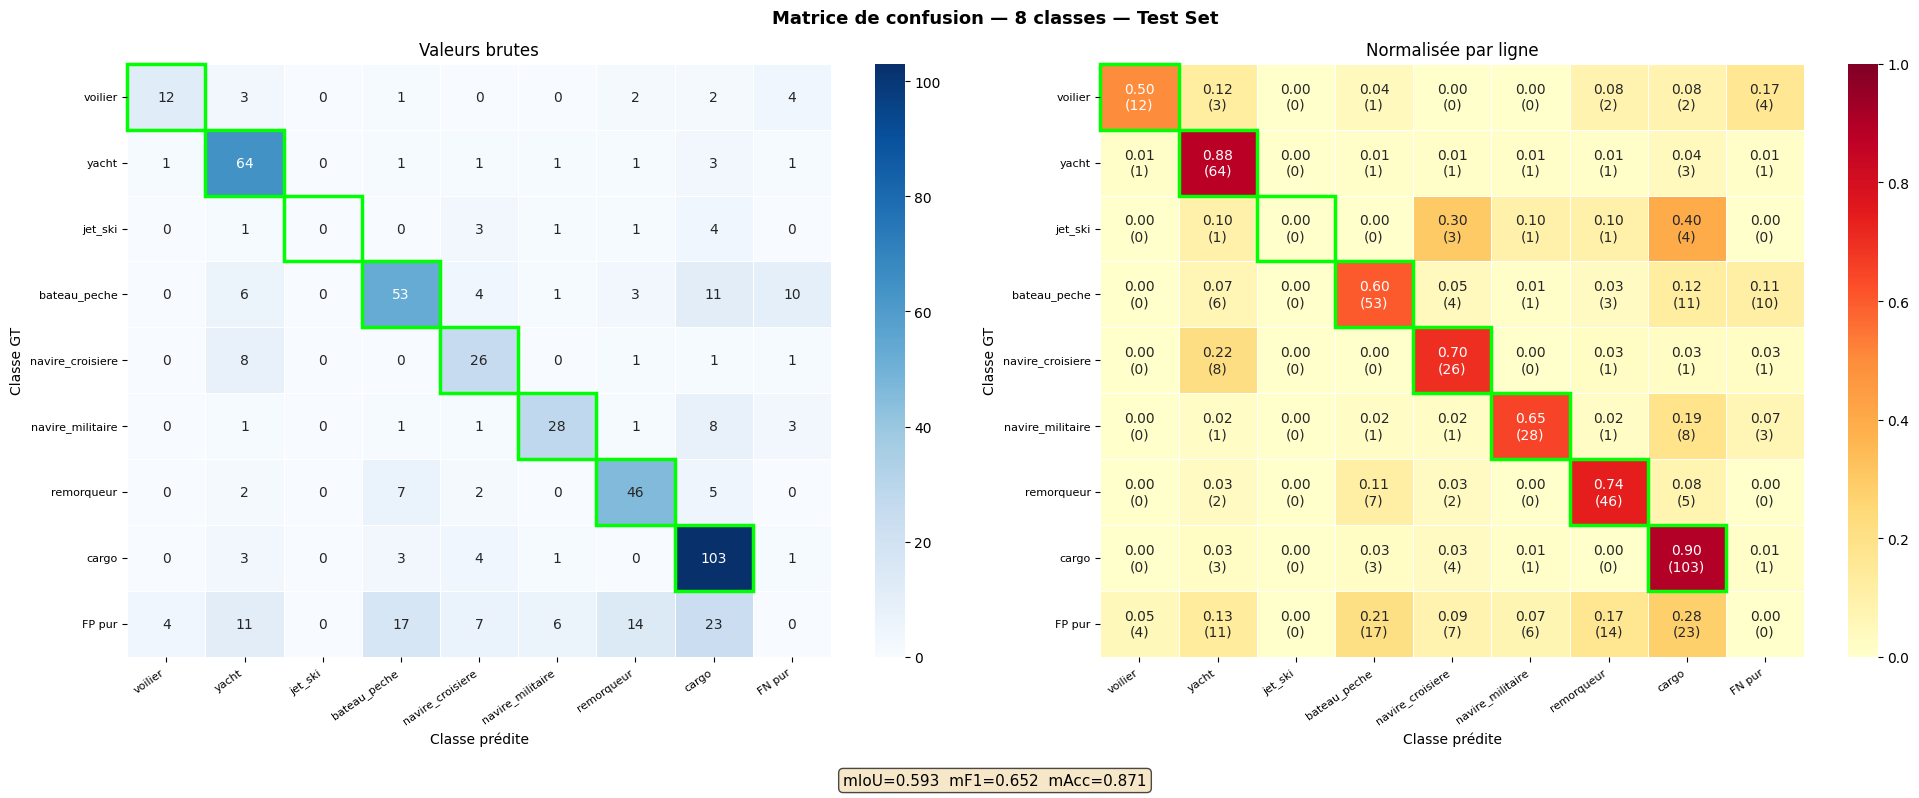

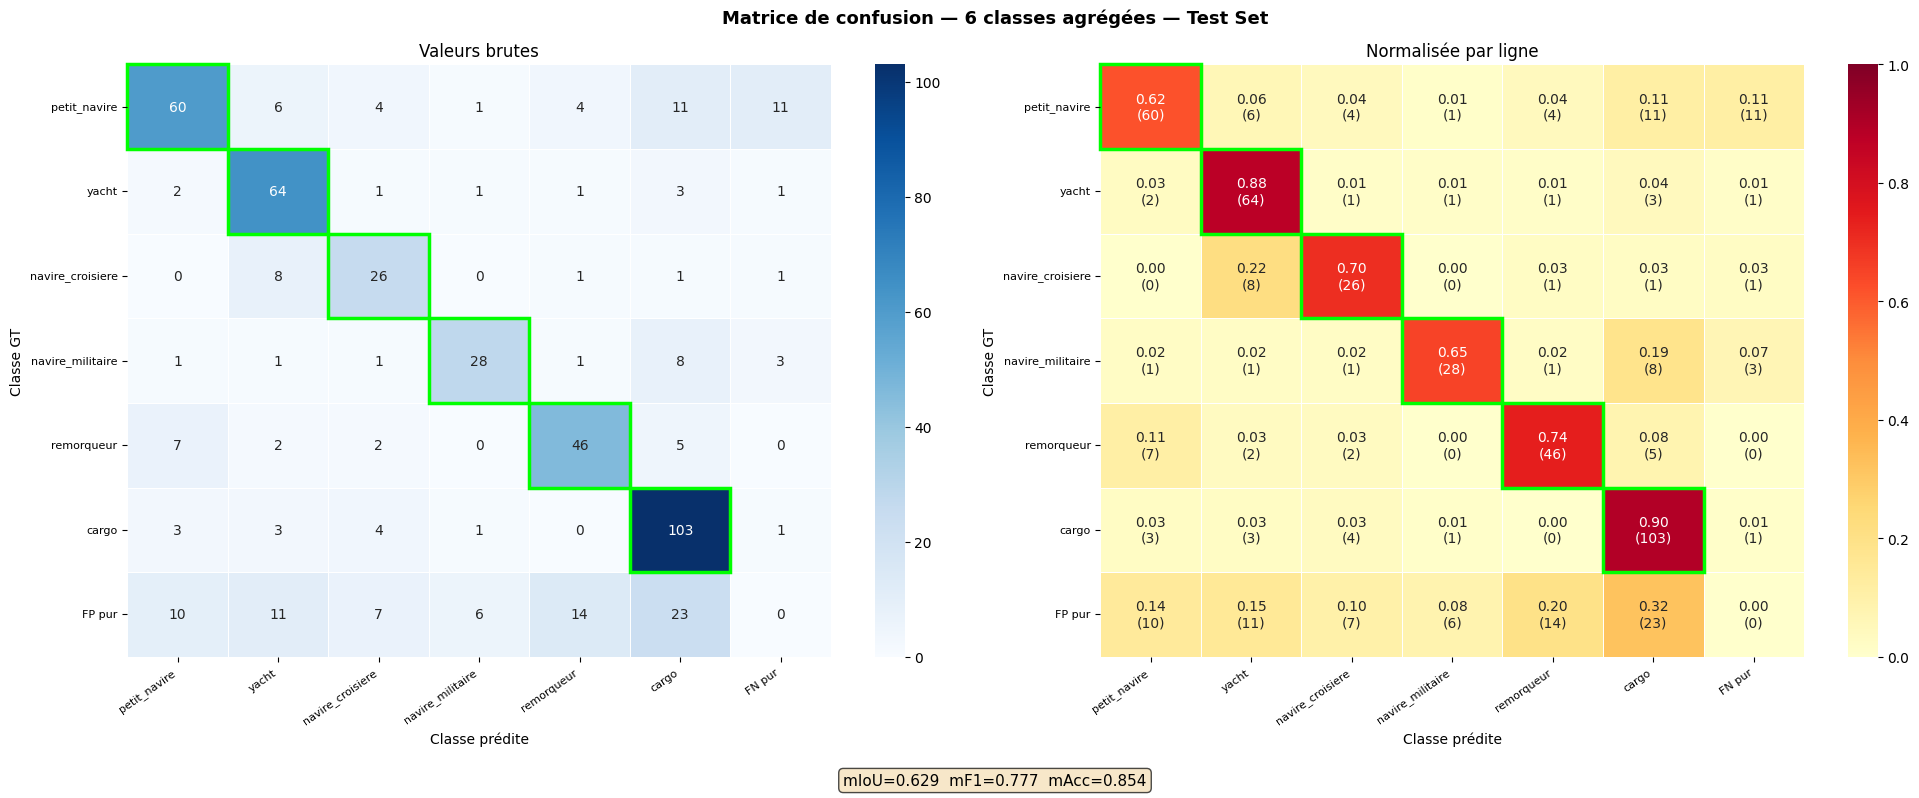

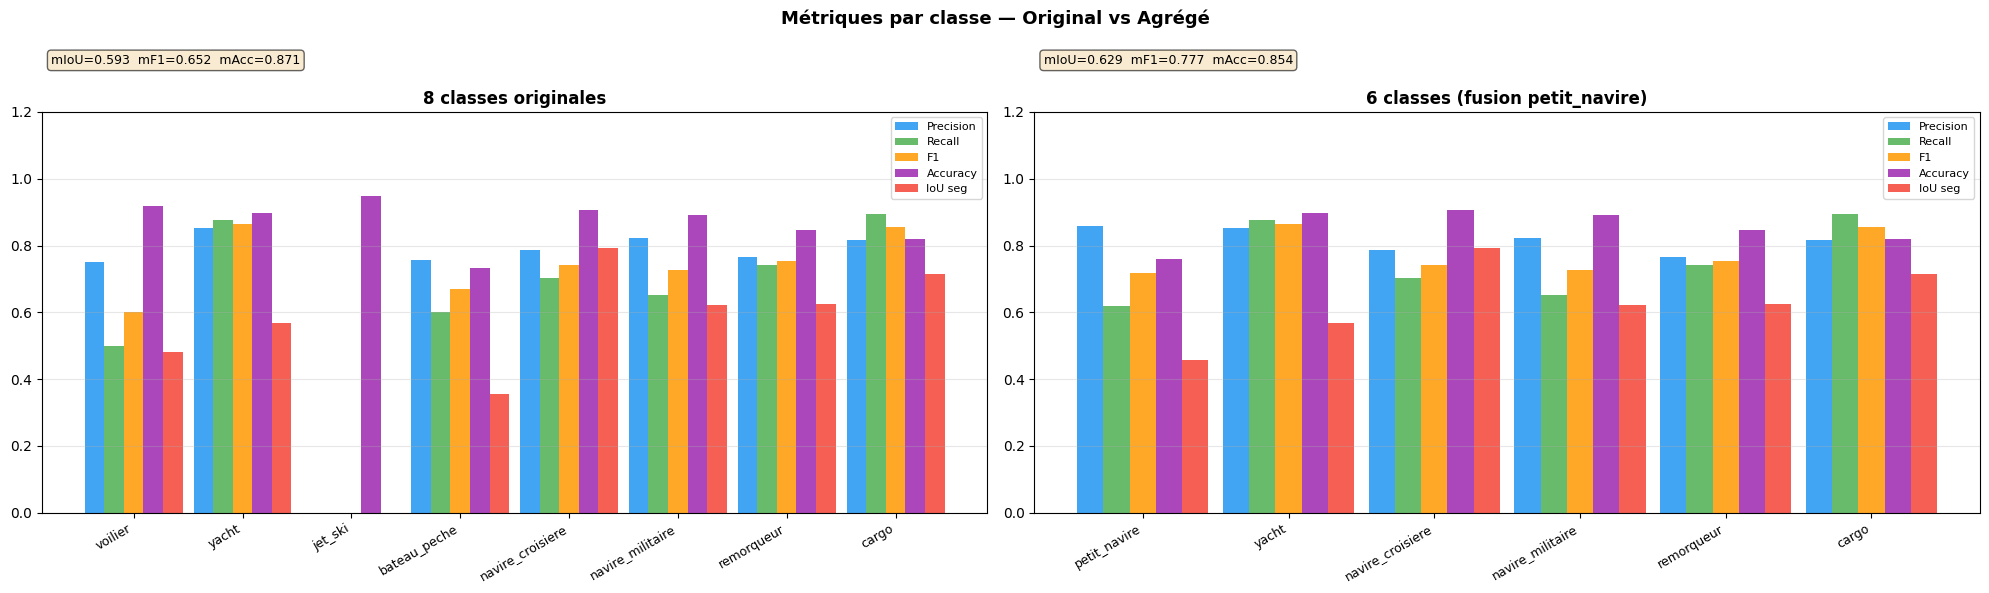

✓ 32 epochs depuis checkpoint_periodique_epoch32.pt


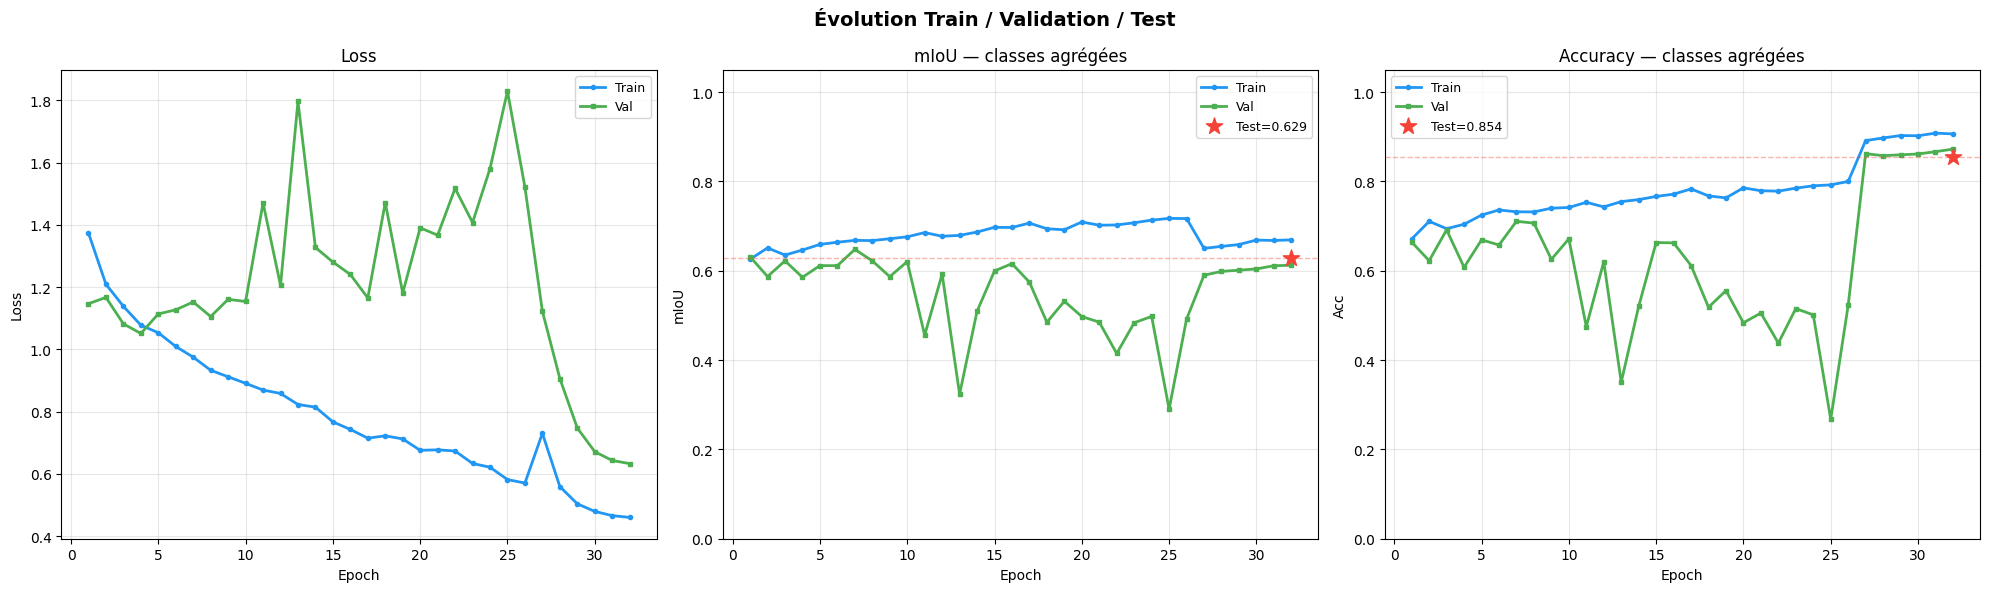


════════════════════════════════════════════════════════════
  COMPARAISON TEST SET : Original vs Agrégé
════════════════════════════════════════════════════════════
  Métrique           8 classes    6 classes        Δ
  --------------------------------------------------
  mIoU                  0.5932       0.6292  +0.0361
  mF1                   0.6518       0.7771  +0.1252
  mPrecision            0.6945       0.8177  +0.1232
  mRecall               0.6213       0.7478  +0.1265
  mAccuracy             0.8705       0.8538  -0.0167
════════════════════════════════════════════════════════════

📁 Résultats dans /home/jupyter-p2m/evaluation/


In [15]:
# ════════════════════════════════════════════════════════════════════════════
# ÉVALUATION SAM3 — AVEC AGRÉGATION DE CLASSES
#
# Agrégation : voilier + jet_ski + bateau_peche → "petit_navire"
# Justification : ces 3 classes partagent des caractéristiques communes
#   - Petite taille en vue aérienne
#   - Usage récréatif / pêche (vs transport commercial)
#   - Souvent amarrés dans les mêmes zones portuaires
#
# Deux évaluations produites :
#   1. Métriques originales (8 classes)
#   2. Métriques agrégées (6 classes : 5 originales + 1 fusionnée)
# ════════════════════════════════════════════════════════════════════════════

import os, glob, re, torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

os.chdir("/home/jupyter-p2m")
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

DEVICE         = 'cuda'
CHECKPOINT_DIR = '/home/jupyter-p2m/checkpoints2'
BEST_MODEL     = f'{CHECKPOINT_DIR}/sam3_semantic_best.pt'
SEUIL_PRESENCE = 0.5
NC             = len(CLASS_NAMES)
OUTPUT_DIR     = '/home/jupyter-p2m/evaluation'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Définition de l'agrégation ────────────────────────────────────────────
# Classes fusionnées → nouvelle classe "petit_navire"
CLASSES_FUSIONNEES = ['voilier', 'jet_ski', 'bateau_peche']
NOM_FUSION         = 'petit_navire'

# Classes dans le schéma agrégé (ordre pour affichage)
CLASSES_AGREGEES = [
    'petit_navire',        # fusion voilier + jet_ski + bateau_peche
    'yacht',
    'navire_croisiere',
    'navire_militaire',
    'remorqueur',
    'cargo',
]
NC_AGG = len(CLASSES_AGREGEES)

# Indices originaux des classes fusionnées
IDX_FUSIONNE = [CLASS_NAMES.index(c) for c in CLASSES_FUSIONNEES]
# Indices des classes non fusionnées (dans l'ordre)
CLASSES_RESTANTES = [c for c in CLASS_NAMES if c not in CLASSES_FUSIONNEES]
IDX_RESTANTS  = [CLASS_NAMES.index(c) for c in CLASSES_RESTANTES]


# ════════════════════════════════════════════════════════════════════════════
# CHARGEMENT MODÈLE
# ════════════════════════════════════════════════════════════════════════════

from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics.models.sam.sam3.geometry_encoders import Prompt

overrides = dict(conf=0.25, task="segment", mode="predict",
                 model="/home/jupyter-p2m/sam3.pt",
                 save=False, imgsz=1008, half=True)
predictor = SAM3SemanticPredictor(overrides=overrides)
dummy_img = next(glob.iglob(f'{DATASET_DIR}/train/**/*.png', recursive=True))
predictor.set_image(dummy_img)
sam = predictor.model.to(DEVICE)

if os.path.exists(BEST_MODEL):
    sam.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))
    print(f"✅ Poids chargés")
else:
    print("⚠️  Modèle de base")

sam.set_classes(text=PROMPTS_CLASSES)
sam.eval()


# ════════════════════════════════════════════════════════════════════════════
# UTILITAIRES
# ════════════════════════════════════════════════════════════════════════════

def detach_features(feats):
    out = {}
    for k, v in feats.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.detach().requires_grad_(False)
        elif isinstance(v, list):
            out[k] = [vi.detach().requires_grad_(False)
                      if isinstance(vi, torch.Tensor) else vi for vi in v]
        else:
            out[k] = v
    return out

@torch.no_grad()
def run_one_class_eval(sam, feats, c):
    geo = Prompt(
        box_embeddings=torch.zeros(0, 1, 4, device=DEVICE),
        box_mask=torch.zeros(1, 0, device=DEVICE, dtype=torch.bool),
    )
    return sam.forward_grounding(
        backbone_out=feats,
        text_ids=torch.tensor([c], device=DEVICE, dtype=torch.long),
        geometric_prompt=geo,
    )


# ════════════════════════════════════════════════════════════════════════════
# AGRÉGATION
#
# Pour une image donnée :
#   GT_fusionne  = 1 si AU MOINS UNE des classes fusionnées est présente
#   PRED_fusionne = 1 si AU MOINS UNE des classes fusionnées est détectée
#
#   IoU_fusionne = max(IoU_voilier, IoU_jet_ski, IoU_bateau_peche)
#   → on prend le meilleur masque parmi les 3 classes
# ════════════════════════════════════════════════════════════════════════════

def agreger_predictions(pred_presence, pred_iou, gt_presence):
    """
    Convertit les prédictions 8 classes → 6 classes agrégées.

    Retourne :
      pred_pres_agg [6] bool
      pred_iou_agg  [6] float
      gt_pres_agg   [6] bool
    """
    pred_pres_agg = np.zeros(NC_AGG, dtype=bool)
    pred_iou_agg  = np.zeros(NC_AGG, dtype=np.float64)
    gt_pres_agg   = np.zeros(NC_AGG, dtype=bool)

    # Classe 0 : petit_navire (fusion)
    pred_pres_agg[0] = any(pred_presence[i] for i in IDX_FUSIONNE)
    pred_iou_agg[0]  = max(pred_iou[i] for i in IDX_FUSIONNE)
    gt_pres_agg[0]   = any(gt_presence[i] for i in IDX_FUSIONNE)

    # Classes 1-5 : classes restantes dans l'ordre
    for agg_idx, orig_idx in enumerate(IDX_RESTANTS, start=1):
        pred_pres_agg[agg_idx] = pred_presence[orig_idx]
        pred_iou_agg[agg_idx]  = pred_iou[orig_idx]
        gt_pres_agg[agg_idx]   = gt_presence[orig_idx]

    return pred_pres_agg, pred_iou_agg, gt_pres_agg


# ════════════════════════════════════════════════════════════════════════════
# ÉVALUATION
# ════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def evaluer_loader(sam, loader, nom_split):
    """
    Retourne deux jeux de résultats :
      res_orig  : métriques sur les 8 classes originales
      res_agg   : métriques sur les 6 classes agrégées
    """
    sam.eval()

    # ── Compteurs 8 classes ───────────────────────────────────────────
    TP_o = np.zeros(NC,     dtype=np.int64)
    FP_o = np.zeros(NC,     dtype=np.int64)
    FN_o = np.zeros(NC,     dtype=np.int64)
    TN_o = np.zeros(NC,     dtype=np.int64)
    conf_o       = np.zeros((NC + 1, NC + 1),     dtype=np.int64)
    iou_somme_o  = np.zeros(NC,     dtype=np.float64)
    iou_cpt_o    = np.zeros(NC,     dtype=np.int64)

    # ── Compteurs 6 classes agrégées ─────────────────────────────────
    TP_a = np.zeros(NC_AGG, dtype=np.int64)
    FP_a = np.zeros(NC_AGG, dtype=np.int64)
    FN_a = np.zeros(NC_AGG, dtype=np.int64)
    TN_a = np.zeros(NC_AGG, dtype=np.int64)
    conf_a       = np.zeros((NC_AGG + 1, NC_AGG + 1), dtype=np.int64)
    iou_somme_a  = np.zeros(NC_AGG, dtype=np.float64)
    iou_cpt_a    = np.zeros(NC_AGG, dtype=np.int64)

    pbar = tqdm(loader, desc=f'Éval [{nom_split}]')
    for batch in pbar:
        img      = batch['image'].to(DEVICE)
        gt_masks = batch['gt_masks'].to(DEVICE)
        presence = batch['presence'].to(DEVICE)

        with torch.amp.autocast('cuda'):
            img_fp16      = img[0].unsqueeze(0).half()
            full_features = sam.backbone(img_fp16, captions=PROMPTS_CLASSES)
            del img_fp16
        feats = detach_features(full_features)
        del full_features
        torch.cuda.empty_cache()

        pred_presence = np.zeros(NC, dtype=bool)
        pred_iou      = np.zeros(NC, dtype=np.float64)

        for c in range(NC):
            torch.cuda.empty_cache()
            try:
                with torch.amp.autocast('cuda'):
                    out_c = run_one_class_eval(sam, feats, c)

                score = torch.sigmoid(
                    out_c['presence_logit_dec'][0, 0]
                ).item()
                pred_presence[c] = score > SEUIL_PRESENCE

                if pred_presence[c] or presence[0, c].item() > 0.5:
                    pred_m = out_c['pred_masks']
                    H      = pred_m.shape[-1]
                    gt_c   = gt_masks[0, c]
                    if gt_c.shape[-1] != H:
                        gt_c = F.interpolate(
                            gt_c.unsqueeze(0).unsqueeze(0).float(),
                            size=(H, H), mode='bilinear',
                            align_corners=False
                        ).squeeze(0).squeeze(0)
                    p_bin  = (torch.sigmoid(pred_m[0]) > 0.5).float()
                    gt_exp = gt_c.unsqueeze(0)
                    inter  = (p_bin * gt_exp).sum(dim=(-2, -1))
                    union  = (p_bin + gt_exp).clamp(0,1).sum(dim=(-2,-1))
                    pred_iou[c] = (inter / (union + 1e-6)).max().item()

                del out_c
                torch.cuda.empty_cache()
            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()

        del feats
        torch.cuda.empty_cache()

        gt_pres = (presence[0].cpu().numpy() > 0.5)

        # ── Remplir compteurs 8 classes ───────────────────────────────
        for c in range(NC):
            gt_c   = bool(gt_pres[c])
            pred_c = bool(pred_presence[c])
            if gt_c and pred_c:
                TP_o[c] += 1
                conf_o[c, c] += 1
                iou_somme_o[c] += pred_iou[c]
                iou_cpt_o[c]   += 1
            elif gt_c and not pred_c:
                FN_o[c] += 1
                autres = [j for j in range(NC)
                          if j != c and pred_presence[j]
                          and pred_iou[j] > 0.10]
                if autres:
                    best_j = max(autres, key=lambda j: pred_iou[j])
                    conf_o[c, best_j] += 1
                else:
                    conf_o[c, NC] += 1
            elif not gt_c and pred_c:
                FP_o[c] += 1
                conf_o[NC, c] += 1
            else:
                TN_o[c] += 1

        # ── Agréger et remplir compteurs 6 classes ────────────────────
        pred_pres_agg, pred_iou_agg, gt_pres_agg = agreger_predictions(
            pred_presence, pred_iou, gt_pres
        )

        for a in range(NC_AGG):
            gt_a   = bool(gt_pres_agg[a])
            pred_a = bool(pred_pres_agg[a])
            if gt_a and pred_a:
                TP_a[a] += 1
                conf_a[a, a] += 1
                iou_somme_a[a] += pred_iou_agg[a]
                iou_cpt_a[a]   += 1
            elif gt_a and not pred_a:
                FN_a[a] += 1
                autres = [j for j in range(NC_AGG)
                          if j != a and pred_pres_agg[j]
                          and pred_iou_agg[j] > 0.10]
                if autres:
                    best_j = max(autres, key=lambda j: pred_iou_agg[j])
                    conf_a[a, best_j] += 1
                else:
                    conf_a[a, NC_AGG] += 1
            elif not gt_a and pred_a:
                FP_a[a] += 1
                conf_a[NC_AGG, a] += 1
            else:
                TN_a[a] += 1

    res_orig = {
        'conf': conf_o,
        'TP': TP_o.astype(float), 'FP': FP_o.astype(float),
        'FN': FN_o.astype(float), 'TN': TN_o.astype(float),
        'iou_somme': iou_somme_o, 'iou_compteur': iou_cpt_o,
        'class_names': CLASS_NAMES,
    }
    res_agg = {
        'conf': conf_a,
        'TP': TP_a.astype(float), 'FP': FP_a.astype(float),
        'FN': FN_a.astype(float), 'TN': TN_a.astype(float),
        'iou_somme': iou_somme_a, 'iou_compteur': iou_cpt_a,
        'class_names': CLASSES_AGREGEES,
    }
    return res_orig, res_agg


# ════════════════════════════════════════════════════════════════════════════
# MÉTRIQUES
# ════════════════════════════════════════════════════════════════════════════

def calculer_metriques(res):
    TP = res['TP']; FP = res['FP']
    FN = res['FN']; TN = res['TN']
    nc = len(res['class_names'])

    precision = np.where(TP+FP > 0, TP/(TP+FP+1e-9), 0.0)
    recall    = np.where(TP+FN > 0, TP/(TP+FN+1e-9), 0.0)
    f1        = np.where(precision+recall > 0,
                         2*precision*recall/(precision+recall+1e-9), 0.0)
    accuracy  = (TP+TN) / (TP+FP+FN+TN+1e-9)
    iou_seg   = np.where(res['iou_compteur'] > 0,
                         res['iou_somme']/(res['iou_compteur']+1e-9), 0.0)
    valid     = res['iou_compteur'] > 0

    return {
        'precision' : precision, 'recall'    : recall,
        'f1'        : f1,        'accuracy'  : accuracy,
        'iou_seg'   : iou_seg,
        'mIoU'      : float(np.mean(iou_seg[valid])) if valid.any() else 0.0,
        'mF1'       : float(np.mean(f1)),
        'mPrecision': float(np.mean(precision)),
        'mRecall'   : float(np.mean(recall)),
        'mAccuracy' : float(np.mean(accuracy)),
    }


# ════════════════════════════════════════════════════════════════════════════
# AFFICHAGE
# ════════════════════════════════════════════════════════════════════════════

def afficher_tableau(m, res, titre):
    noms = res['class_names']
    print(f"\n{'═'*100}")
    print(f"  {titre}")
    print(f"{'═'*100}")
    print(f"  {'Classe':<22} {'Precision':>9} {'Recall':>9} {'F1':>9} "
          f"{'Accuracy':>9} {'IoU seg':>9}  │  "
          f"{'TP':>5} {'FP':>5} {'FN':>5} {'TN':>5}")
    print(f"  {'-'*98}")
    for i, cls in enumerate(noms):
        print(
            f"  {cls:<22} "
            f"{m['precision'][i]:>9.3f} "
            f"{m['recall'][i]:>9.3f} "
            f"{m['f1'][i]:>9.3f} "
            f"{m['accuracy'][i]:>9.3f} "
            f"{m['iou_seg'][i]:>9.3f}  │  "
            f"{int(res['TP'][i]):>5d} "
            f"{int(res['FP'][i]):>5d} "
            f"{int(res['FN'][i]):>5d} "
            f"{int(res['TN'][i]):>5d}"
        )
    print(f"  {'─'*98}")
    print(
        f"  {'MACRO MOYENNE':<22} "
        f"{m['mPrecision']:>9.3f} "
        f"{m['mRecall']:>9.3f} "
        f"{m['mF1']:>9.3f} "
        f"{m['mAccuracy']:>9.3f} "
        f"{m['mIoU']:>9.3f}"
    )
    print(f"{'═'*100}")


def plot_confusion(res, m, titre, save_path=None):
    nc   = len(res['class_names'])
    noms = res['class_names']
    cm_int  = res['conf']
    cm_float = cm_int.astype(np.float64)
    row_sum  = cm_float.sum(axis=1, keepdims=True)
    cm_norm  = np.divide(cm_float, row_sum, where=row_sum > 0)

    labels_y = noms + ['FP pur']
    labels_x = noms + ['FN pur']

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'Matrice de confusion — {titre}',
                 fontsize=13, fontweight='bold')

    sns.heatmap(cm_int, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_x, yticklabels=labels_y,
                ax=axes[0], linewidths=0.5)
    axes[0].set_title('Valeurs brutes')
    axes[0].set_xlabel('Classe prédite')
    axes[0].set_ylabel('Classe GT')
    axes[0].set_xticklabels(labels_x, rotation=35, ha='right', fontsize=8)
    axes[0].set_yticklabels(labels_y, rotation=0, fontsize=8)

    annot = np.array([
        [f'{cm_norm[i,j]:.2f}\n({int(cm_int[i,j])})'
         for j in range(nc + 1)]
        for i in range(nc + 1)
    ])
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='YlOrRd',
                xticklabels=labels_x, yticklabels=labels_y,
                ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
    axes[1].set_title('Normalisée par ligne')
    axes[1].set_xlabel('Classe prédite')
    axes[1].set_ylabel('Classe GT')
    axes[1].set_xticklabels(labels_x, rotation=35, ha='right', fontsize=8)
    axes[1].set_yticklabels(labels_y, rotation=0, fontsize=8)

    for ax in axes:
        for i in range(nc):
            ax.add_patch(plt.Rectangle(
                (i, i), 1, 1, fill=False,
                edgecolor='lime', lw=2.5, clip_on=False
            ))

    # Annotation résumé métriques
    fig.text(0.5, 0.01,
             f"mIoU={m['mIoU']:.3f}  mF1={m['mF1']:.3f}  "
             f"mAcc={m['mAccuracy']:.3f}",
             ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_barres(m_orig, m_agg, save_path=None):
    """Compare les métriques avant/après agrégation."""
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    fig.suptitle('Métriques par classe — Original vs Agrégé',
                 fontsize=13, fontweight='bold')

    for ax, m, noms, titre in [
        (axes[0], m_orig, CLASS_NAMES,     '8 classes originales'),
        (axes[1], m_agg,  CLASSES_AGREGEES, f'6 classes (fusion {NOM_FUSION})'),
    ]:
        x     = np.arange(len(noms))
        width = 0.18
        ax.bar(x-2*width, m['precision'], width, label='Precision',
               color='#2196F3', alpha=0.85)
        ax.bar(x-  width, m['recall'],    width, label='Recall',
               color='#4CAF50', alpha=0.85)
        ax.bar(x,          m['f1'],        width, label='F1',
               color='#FF9800', alpha=0.85)
        ax.bar(x+  width, m['accuracy'],  width, label='Accuracy',
               color='#9C27B0', alpha=0.85)
        ax.bar(x+2*width, m['iou_seg'],   width, label='IoU seg',
               color='#F44336', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(noms, rotation=30, ha='right', fontsize=9)
        ax.set_ylim(0, 1.2)
        ax.set_title(titre, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)
        ax.text(0.01, 1.12,
                f"mIoU={m['mIoU']:.3f}  mF1={m['mF1']:.3f}  "
                f"mAcc={m['mAccuracy']:.3f}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# COURBES ÉVOLUTION
# ════════════════════════════════════════════════════════════════════════════

def charger_history():
    tous = []
    for p in [f'{CHECKPOINT_DIR}/checkpoint_early*.pt',
              f'{CHECKPOINT_DIR}/checkpoint_arret*.pt',
              f'{CHECKPOINT_DIR}/checkpoint_periodique*.pt',
              f'{CHECKPOINT_DIR}/checkpoint_epoch*.pt']:
        tous += glob.glob(p)
    if not tous:
        return []
    def ep(x):
        m = re.search(r'epoch(\d+)', os.path.basename(x))
        return int(m.group(1)) if m else 0
    dernier = sorted(tous, key=ep)[-1]
    h = torch.load(dernier, map_location='cpu').get('history', [])
    print(f"✓ {len(h)} epochs depuis {os.path.basename(dernier)}")
    return h

def plot_courbes(history, m_val_agg, m_test_agg, save_path=None):
    if not history:
        return
    epochs  = [h['epoch']      for h in history]
    tr_iou  = [h['train_iou']  for h in history]
    vl_iou  = [h['val_iou']    for h in history]
    tr_acc  = [h['train_acc']  for h in history]
    vl_acc  = [h['val_acc']    for h in history]
    tr_loss = [h['train_loss'] for h in history]
    vl_loss = [h['val_loss']   for h in history]
    last    = epochs[-1]
    C       = {'train': '#2196F3', 'val': '#4CAF50', 'test': '#F44336'}

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Évolution Train / Validation / Test',
                 fontsize=14, fontweight='bold')

    for ax, tr, vl, te, yl, title in [
        (axes[0], tr_loss, vl_loss, None,
         'Loss', 'Loss'),
        (axes[1], tr_iou, vl_iou, m_test_agg['mIoU'],
         'mIoU', 'mIoU — classes agrégées'),
        (axes[2], tr_acc, vl_acc, m_test_agg['mAccuracy'],
         'Acc',  'Accuracy — classes agrégées'),
    ]:
        ax.plot(epochs, tr, color=C['train'], lw=2,
                marker='o', ms=3, label='Train')
        ax.plot(epochs, vl, color=C['val'],   lw=2,
                marker='s', ms=3, label='Val')
        if te is not None:
            ax.scatter([last], [te], color=C['test'],
                       s=150, zorder=5, marker='*',
                       label=f'Test={te:.3f}')
            ax.axhline(te, color=C['test'], ls='--', alpha=0.4, lw=1)
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.set_ylabel(yl);   ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        if yl != 'Loss':
            ax.set_ylim(bottom=0, top=1.05)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# LANCEMENT
# ════════════════════════════════════════════════════════════════════════════

print("\n📊 TEST SET...")
res_test_orig, res_test_agg = evaluer_loader(sam, test_loader, 'TEST')
m_test_orig = calculer_metriques(res_test_orig)
m_test_agg  = calculer_metriques(res_test_agg)

print("\n📊 VAL SET...")
res_val_orig, res_val_agg = evaluer_loader(sam, val_loader, 'VAL')
m_val_orig = calculer_metriques(res_val_orig)
m_val_agg  = calculer_metriques(res_val_agg)

# ── Tableaux ──────────────────────────────────────────────────────────────
afficher_tableau(m_test_orig, res_test_orig, 'TEST SET — 8 classes originales')
afficher_tableau(m_test_agg,  res_test_agg,
                 f'TEST SET — 6 classes ({NOM_FUSION} = voilier+jet_ski+bateau_peche)')

afficher_tableau(m_val_orig,  res_val_orig,  'VAL SET — 8 classes originales')
afficher_tableau(m_val_agg,   res_val_agg,
                 f'VAL SET — 6 classes ({NOM_FUSION})')

# ── Matrices de confusion ─────────────────────────────────────────────────
plot_confusion(
    res_test_orig, m_test_orig,
    '8 classes — Test Set',
    save_path=f'{OUTPUT_DIR}/confusion_8classes_test.png'
)
plot_confusion(
    res_test_agg, m_test_agg,
    f'6 classes agrégées — Test Set',
    save_path=f'{OUTPUT_DIR}/confusion_6classes_test.png'
)

# ── Comparaison barres ────────────────────────────────────────────────────
plot_barres(
    m_test_orig, m_test_agg,
    save_path=f'{OUTPUT_DIR}/comparaison_agregation_test.png'
)

# ── Courbes évolution ─────────────────────────────────────────────────────
history = charger_history()
plot_courbes(
    history, m_val_agg, m_test_agg,
    save_path=f'{OUTPUT_DIR}/courbes_evolution_agg.png'
)

# ── Résumé comparatif ─────────────────────────────────────────────────────
print(f"\n{'═'*60}")
print(f"  COMPARAISON TEST SET : Original vs Agrégé")
print(f"{'═'*60}")
print(f"  {'Métrique':<15} {'8 classes':>12} {'6 classes':>12} {'Δ':>8}")
print(f"  {'-'*50}")
for nom, k in [('mIoU','mIoU'), ('mF1','mF1'),
               ('mPrecision','mPrecision'), ('mRecall','mRecall'),
               ('mAccuracy','mAccuracy')]:
    v8 = m_test_orig[k]; v6 = m_test_agg[k]
    print(f"  {nom:<15} {v8:>12.4f} {v6:>12.4f} {v6-v8:>+8.4f}")
print(f"{'═'*60}")
print(f"\n📁 Résultats dans {OUTPUT_DIR}/")

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FINE-TUNING SAM3 — VERSION FINALE OPTIMISÉE
#
# Corrections vs version précédente :
#   1. LR cyclique (CyclicLR) au lieu de ReduceLROnPlateau
#      → sort des plateaux en oscillant entre LR_min et LR_max
#   2. Dégel partiel du backbone (2 dernières couches du transformer visuel)
#      → permet au modèle d'adapter les features visuelles au domaine maritime
#   3. Patience augmentée : 10 → 20
#   4. EMA decay réduit : 0.999 → 0.99 (intègre plus vite les nouvelles infos)
#   5. Calcul val IoU corrigé : on moyenne uniquement les classes présentes
#      ET on ajoute une métrique globale pour éviter le biais des None
#   6. Sauvegarder le meilleur modèle si amélioration > 0.001 (seuil minimal)
# ════════════════════════════════════════════════════════════════════════════

import os, glob, re, torch, copy
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.checkpoint import checkpoint
from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics.models.sam.sam3.geometry_encoders import Prompt
from tqdm import tqdm

os.chdir("/home/jupyter-p2m")
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

DEVICE         = 'cuda'
CHECKPOINT_DIR = '/home/jupyter-p2m/checkpoints2'
BEST_MODEL     = f'{CHECKPOINT_DIR}/sam3_semantic_best.pt'
NC             = len(CLASS_NAMES)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


# ════════════════════════════════════════════════════════════════════════════
# CHARGEMENT MODÈLE
# ════════════════════════════════════════════════════════════════════════════

overrides = dict(conf=0.25, task="segment", mode="predict",
                 model="/home/jupyter-p2m/sam3.pt",
                 save=False, imgsz=1008, half=True)
predictor = SAM3SemanticPredictor(overrides=overrides)
dummy_img  = next(glob.iglob(f'{DATASET_DIR}/train/**/*.png', recursive=True))
predictor.set_image(dummy_img)
sam = predictor.model.to(DEVICE)

if os.path.exists(BEST_MODEL):
    sam.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))
    print(f"✅ Meilleurs poids chargés")
else:
    print("⚠️  Poids de base SAM3")


# ════════════════════════════════════════════════════════════════════════════
# STRATÉGIE DE GEL — DÉGEL PARTIEL DU BACKBONE
#
# Avant : backbone entièrement gelé → le modèle ne peut adapter que le
#         Detector, pas les features visuelles
# Maintenant : on dégèle les 2 derniers blocs du vision transformer
#              → le backbone peut s'adapter légèrement au domaine maritime
#              sans perdre ses connaissances générales
# ════════════════════════════════════════════════════════════════════════════

def configurer_gel(sam, n_blocs_degeles=0):
    """
    Gèle tout le backbone sauf les n_blocs_degeles derniers blocs
    du vision transformer.
    """
    # Geler tout d'abord
    for param in sam.parameters():
        param.requires_grad = False

    # Dégeler le Detector (toujours entraîné)
    for name, param in sam.named_parameters():
        if 'backbone' not in name:
            param.requires_grad = True

    # Dégeler les derniers blocs du vision backbone
    blocs_degeles = 0
    vision_blocks = []
    for name, module in sam.named_modules():
        if 'backbone' in name and 'vision' in name:
            if hasattr(module, 'blocks'):
                vision_blocks = list(module.blocks.named_children())
                break

    if vision_blocks:
        for block_name, block in vision_blocks[-n_blocs_degeles:]:
            for param in block.parameters():
                param.requires_grad = True
            blocs_degeles += 1
        print(f"  ✅ {blocs_degeles} blocs vision dégelés")
    else:
        print("  ⚠️  Structure backbone non trouvée — Detector seul entraîné")

    # Cast fp32 pour tous les params entraînables
    for name, param in sam.parameters() if False else sam.named_parameters():
        if param.requires_grad:
            param.data = param.data.float()

    trainable = sum(p.numel() for p in sam.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in sam.parameters())
    print(f"  Entraînables : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
    return trainable

# CORRECTION : backbone entièrement gelé
# Le dégel partiel dégradait les features visuelles (fp16→fp32 instable)
trainable = configurer_gel(sam, n_blocs_degeles=0)
sam.set_classes(text=PROMPTS_CLASSES)


# ════════════════════════════════════════════════════════════════════════════
# EMA — decay réduit pour intégrer plus vite les nouvelles infos
# ════════════════════════════════════════════════════════════════════════════

class EMA:
    def __init__(self, model, decay=0.99):
        self.decay  = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.shadow[name] = (
                    self.decay * self.shadow[name] +
                    (1 - self.decay) * param.data
                )

    def apply(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]

    def restore(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.backup:
                param.data = self.backup[name]
        self.backup = {}

ema = EMA(sam, decay=0.99)
print("✅ EMA initialisé (decay=0.99)")


# ════════════════════════════════════════════════════════════════════════════
# POIDS CLASSES
# ════════════════════════════════════════════════════════════════════════════

POIDS_CLASSES = {
    'voilier'         : 2.5,
    'yacht'           : 1.0,
    'jet_ski'         : 3.5,
    'bateau_peche'    : 1.2,
    'navire_croisiere': 1.5,
    'navire_militaire': 1.3,
    'remorqueur'      : 1.2,
    'cargo'           : 0.8,
}
class_weights_gpu = torch.tensor(
    [POIDS_CLASSES[cls] for cls in CLASS_NAMES],
    dtype=torch.float32
).to(DEVICE)


# ════════════════════════════════════════════════════════════════════════════
# LOSS
# ════════════════════════════════════════════════════════════════════════════

def focal_loss(logits, targets, alpha=1.0, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(
        logits, targets, reduction='none'
    )
    pt = torch.exp(-bce)
    return (alpha * (1 - pt) ** gamma * bce).mean()

def dice_loss(logits, targets, smooth=1e-6):
    p     = torch.sigmoid(logits)
    inter = (p * targets).sum()
    union = p.sum() + targets.sum()
    return 1 - (2 * inter + smooth) / (union + smooth)

def loss_une_classe(out_c, gt_mask_c, presence_c,
                     class_weight=1.0, label_smooth=0.05):
    pred_m = out_c['pred_masks']
    pres_l = out_c['presence_logit_dec']

    H = pred_m.shape[-1]
    if gt_mask_c.shape[-1] != H:
        gt_c = F.interpolate(
            gt_mask_c.unsqueeze(0).unsqueeze(0).float(),
            size=(H, H), mode='bilinear', align_corners=False
        ).squeeze(0).squeeze(0)
    else:
        gt_c = gt_mask_c.float()

    pres_smooth = presence_c * (1 - label_smooth) + label_smooth * 0.5
    pres_loss   = focal_loss(
        pres_l[0, 0].unsqueeze(0),
        pres_smooth.unsqueeze(0),
        alpha=class_weight, gamma=2.0
    )

    if presence_c.item() < 0.5:
        seg_loss = F.binary_cross_entropy_with_logits(
            pred_m[0], torch.zeros_like(pred_m[0])
        ) * 0.02
    else:
        with torch.no_grad():
            p_bin  = (torch.sigmoid(pred_m[0]) > 0.5).float()
            gt_exp = gt_c.unsqueeze(0)
            inter  = (p_bin * gt_exp).sum(dim=(-2, -1))
            union  = (p_bin + gt_exp).clamp(0, 1).sum(dim=(-2, -1))
            best_q = (inter / (union + 1e-6)).argmax()

        best_pred = pred_m[0, best_q]
        gt_smooth = gt_c * (1 - label_smooth) + label_smooth * 0.5
        seg_loss  = (0.5 * focal_loss(best_pred, gt_smooth,
                                       alpha=class_weight, gamma=2.0) +
                     0.5 * dice_loss(best_pred, gt_c))

    return (0.7 * seg_loss + 0.3 * pres_loss) / NC


# ════════════════════════════════════════════════════════════════════════════
# UTILITAIRES
# ════════════════════════════════════════════════════════════════════════════

def detach_features(feats):
    out = {}
    for k, v in feats.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.detach().requires_grad_(False)
        elif isinstance(v, list):
            out[k] = [vi.detach().requires_grad_(False)
                      if isinstance(vi, torch.Tensor) else vi for vi in v]
        else:
            out[k] = v
    return out

def run_one_class(sam, feats, c):
    def _inner(c_t):
        geo = Prompt(
            box_embeddings=torch.zeros(0, 1, 4, device=DEVICE),
            box_mask=torch.zeros(1, 0, device=DEVICE, dtype=torch.bool),
        )
        return sam.forward_grounding(
            backbone_out=feats,
            text_ids=torch.tensor([int(c_t.item())],
                                  device=DEVICE, dtype=torch.long),
            geometric_prompt=geo,
        )
    return checkpoint(_inner,
                      torch.tensor(c, device=DEVICE, dtype=torch.long),
                      use_reentrant=False)

@torch.no_grad()
def metriques_batch(out_c, gt_mask_c, presence_c, seuil=0.5):
    """
    Retourne (iou, correct, presence_pred) pour une classe.
    Correction : on compte aussi les vrais négatifs (TN)
    pour avoir une métrique globale non biaisée.
    """
    pred_score = torch.sigmoid(
        out_c['presence_logit_dec'][0, 0]
    ).item()
    presence_pred = pred_score > seuil
    gt_present    = presence_c.item() > 0.5

    # Accuracy binaire sur la présence (inclut TN)
    correct_pres = float(presence_pred == gt_present)

    if not gt_present:
        return 0.0, correct_pres, False

    # IoU segmentation (uniquement si GT présent)
    pred_m = out_c['pred_masks']
    H      = pred_m.shape[-1]
    gt_c   = gt_mask_c.float()
    if gt_c.shape[-1] != H:
        gt_c = F.interpolate(
            gt_c.unsqueeze(0).unsqueeze(0),
            size=(H, H), mode='bilinear', align_corners=False
        ).squeeze(0).squeeze(0)

    p_bin  = (torch.sigmoid(pred_m[0]) > 0.5).float()
    inter  = (p_bin * gt_c.unsqueeze(0)).sum(dim=(-2, -1))
    union  = (p_bin + gt_c.unsqueeze(0)).clamp(0, 1).sum(dim=(-2, -1))
    iou    = (inter / (union + 1e-6)).max().item()
    return iou, correct_pres, presence_pred


# ════════════════════════════════════════════════════════════════════════════
# TRAIN
# ════════════════════════════════════════════════════════════════════════════

ACCUM_STEPS = 8

def train_one_epoch(sam, loader, optimizer, scaler, scheduler_cyclic, epoch):
    sam.train()
    # Backbone : eval pour les couches gelées, train pour les dégelées
    for name, module in sam.named_modules():
        if 'backbone' in name:
            # Mettre en train seulement les modules avec params entraînables
            has_trainable = any(p.requires_grad
                                for p in module.parameters(recurse=False))
            if has_trainable:
                module.train()
            else:
                module.eval()

    total_loss = 0.0
    all_ious   = []
    all_accs   = []
    n_batch    = 0

    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [TRAIN]')
    for batch_idx, batch in enumerate(pbar):
        img      = batch['image'].to(DEVICE)
        gt_masks = batch['gt_masks'].to(DEVICE)
        presence = batch['presence'].to(DEVICE)

        if batch_idx % ACCUM_STEPS == 0:
            optimizer.zero_grad()

        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                img_fp16      = img[0].unsqueeze(0).half()
                full_features = sam.backbone(img_fp16,
                                             captions=PROMPTS_CLASSES)
                del img_fp16
        feats = detach_features(full_features)
        del full_features
        torch.cuda.empty_cache()

        batch_loss = 0.0
        batch_ious = []
        batch_accs = []
        oom = False

        for c in range(NC):
            torch.cuda.empty_cache()
            try:
                with torch.amp.autocast('cuda'):
                    out_c  = run_one_class(sam, feats, c)
                    loss_c = loss_une_classe(
                        out_c, gt_masks[0, c], presence[0, c],
                        class_weight=class_weights_gpu[c].item(),
                    ) / ACCUM_STEPS

                scaler.scale(loss_c).backward()
                batch_loss += loss_c.item() * NC * ACCUM_STEPS

                iou, acc, _ = metriques_batch(
                    out_c, gt_masks[0, c], presence[0, c]
                )
                batch_ious.append(iou)
                batch_accs.append(acc)

                del out_c, loss_c
                torch.cuda.empty_cache()

            except torch.cuda.OutOfMemoryError:
                print(f"\n⚠️  OOM classe {c} — skip")
                oom = True
                torch.cuda.empty_cache()
                break

        del feats
        torch.cuda.empty_cache()

        if oom:
            optimizer.zero_grad()
            continue

        is_last = (batch_idx + 1 == len(loader))
        if (batch_idx + 1) % ACCUM_STEPS == 0 or is_last:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(sam.parameters(), max_norm=0.5)
            scaler.step(optimizer)
            scaler.update()
            ema.update(sam)
            # Step du scheduler cyclique à chaque optimizer step
            scheduler_cyclic.step()

        total_loss += batch_loss
        all_ious.extend(batch_ious)
        all_accs.extend(batch_accs)
        n_batch += 1

        # Afficher métriques moyennes (pas instantanées)
        mean_iou = float(np.mean([x for x in all_ious if x > 0])) \
                   if any(x > 0 for x in all_ious) else 0.0
        mean_acc = float(np.mean(all_accs)) if all_accs else 0.0
        pbar.set_postfix({
            'loss': f'{total_loss/max(n_batch,1):.4f}',
            'iou' : f'{mean_iou:.4f}',
            'acc' : f'{mean_acc:.4f}',
        })

    if n_batch == 0:
        return 0., 0., 0.
    final_iou = float(np.mean([x for x in all_ious if x > 0])) \
                if any(x > 0 for x in all_ious) else 0.0
    final_acc = float(np.mean(all_accs)) if all_accs else 0.0
    return total_loss / n_batch, final_iou, final_acc


# ════════════════════════════════════════════════════════════════════════════
# VALIDATE — corrigé : moyenne cohérente avec train
# ════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def validate(sam, loader, epoch, use_ema=True):
    if use_ema:
        ema.apply(sam)
    sam.eval()

    total_loss = 0.0
    all_ious   = []
    all_accs   = []
    n_batch    = 0

    pbar = tqdm(loader, desc=f'Epoch {epoch:02d} [VAL]  ')
    for batch in pbar:
        img      = batch['image'].to(DEVICE)
        gt_masks = batch['gt_masks'].to(DEVICE)
        presence = batch['presence'].to(DEVICE)

        with torch.amp.autocast('cuda'):
            img_fp16      = img[0].unsqueeze(0).half()
            full_features = sam.backbone(img_fp16, captions=PROMPTS_CLASSES)
            del img_fp16
        feats = detach_features(full_features)
        del full_features
        torch.cuda.empty_cache()

        batch_loss = 0.0
        batch_ious = []
        batch_accs = []

        for c in range(NC):
            torch.cuda.empty_cache()
            try:
                with torch.amp.autocast('cuda'):
                    out_c  = run_one_class(sam, feats, c)
                    loss_c = loss_une_classe(
                        out_c, gt_masks[0, c], presence[0, c],
                        class_weight=class_weights_gpu[c].item(),
                    )
                batch_loss += loss_c.item() * NC

                iou, acc, _ = metriques_batch(
                    out_c, gt_masks[0, c], presence[0, c]
                )
                batch_ious.append(iou)
                batch_accs.append(acc)

                del out_c, loss_c
                torch.cuda.empty_cache()
            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache()

        del feats
        torch.cuda.empty_cache()

        total_loss += batch_loss
        all_ious.extend(batch_ious)
        all_accs.extend(batch_accs)
        n_batch += 1

        mean_iou = float(np.mean([x for x in all_ious if x > 0])) \
                   if any(x > 0 for x in all_ious) else 0.0
        mean_acc = float(np.mean(all_accs)) if all_accs else 0.0
        pbar.set_postfix({
            'loss': f'{total_loss/max(n_batch,1):.4f}',
            'iou' : f'{mean_iou:.4f}',
            'acc' : f'{mean_acc:.4f}',
        })

    if use_ema:
        ema.restore(sam)

    if n_batch == 0:
        return 0., 0., 0.
    final_iou = float(np.mean([x for x in all_ious if x > 0])) \
                if any(x > 0 for x in all_ious) else 0.0
    final_acc = float(np.mean(all_accs)) if all_accs else 0.0
    return total_loss / n_batch, final_iou, final_acc


# ════════════════════════════════════════════════════════════════════════════
# SAUVEGARDE
# ════════════════════════════════════════════════════════════════════════════

def sauvegarder(sam, optimizer, scheduler_plateau, scheduler_cyclic,
                scaler, epoch, best_iou, history, raison='periodique'):
    path = f'{CHECKPOINT_DIR}/checkpoint_{raison}_epoch{epoch:02d}.pt'
    torch.save({
        'epoch'                  : epoch,
        'model_state'            : sam.state_dict(),
        'ema_shadow'             : ema.shadow,
        'optimizer_state'        : optimizer.state_dict(),
        'scheduler_plateau_state': scheduler_plateau.state_dict(),
        'scheduler_cyclic_state' : scheduler_cyclic.state_dict(),
        'scaler_state'           : scaler.state_dict(),
        'best_iou'               : best_iou,
        'history'                : history,
    }, path)
    return path

def nettoyer(pattern, garder=3):
    ckpts = sorted(glob.glob(pattern))
    for old in ckpts[:-garder]:
        os.remove(old)


# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — LR CYCLIQUE
#
# CyclicLR oscille entre LR_min et LR_max toutes les step_size_up steps
# → force le modèle à explorer différentes régions de l'espace des paramètres
# → sort naturellement des plateaux
#
# Avec 895 batches/epoch et ACCUM_STEPS=8 → ~112 optimizer steps/epoch
# step_size_up = 4 epochs × 112 steps = 448 steps (demi-cycle = 4 epochs)
# ════════════════════════════════════════════════════════════════════════════

EPOCHS         = 50
SAVE_EVERY     = 2
patience       = 20          # augmentée : 10 → 20
SEUIL_AMELIORATION = 0.001  # sauvegarder si amélioration > 0.1%

LR_MIN = 1e-6
LR_MAX = 1e-5                # max modéré pour éviter l'instabilité

scaler = torch.amp.GradScaler('cuda')

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, sam.parameters()),
    lr=LR_MIN,
    weight_decay=1e-3
)

# Scheduler cyclique — sort des plateaux
steps_per_epoch   = len(train_loader) // ACCUM_STEPS
step_size_up      = 4 * steps_per_epoch   # demi-cycle = 4 epochs

scheduler_cyclic  = optim.lr_scheduler.CyclicLR(
    optimizer,
    base_lr    = LR_MIN,
    max_lr     = LR_MAX,
    step_size_up = step_size_up,
    mode       = 'triangular2',   # amplitude réduite de moitié à chaque cycle
    cycle_momentum = False,        # AdamW n'a pas de momentum simple
)

# Scheduler plateau en parallèle — réduit si vraiment bloqué
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5,
    patience=8, min_lr=1e-7,
)


# ════════════════════════════════════════════════════════════════════════════
# REPRISE
# ════════════════════════════════════════════════════════════════════════════

def dernier_ckpt(d):
    tous = []
    for p in [f'{d}/checkpoint_early*.pt',
              f'{d}/checkpoint_arret*.pt',
              f'{d}/checkpoint_periodique*.pt']:
        tous += glob.glob(p)
    if not tous:
        return None
    def ep(x):
        m = re.search(r'epoch(\d+)', os.path.basename(x))
        return int(m.group(1)) if m else 0
    return sorted(tous, key=ep)[-1]

ckpt_path = dernier_ckpt(CHECKPOINT_DIR)
if ckpt_path:
    print(f"\n✓ Reprise : {os.path.basename(ckpt_path)}")
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    if 'ema_shadow' in ckpt:
        ema.shadow = {k: v.to(DEVICE) for k, v in ckpt['ema_shadow'].items()}
        print("  ✓ EMA restauré")
    # Charger l'optimizer seulement si le nb de params correspond
    # (incompatible si on a changé les couches entraînées)
    try:
        optimizer.load_state_dict(ckpt['optimizer_state'])
        for pg in optimizer.param_groups:
            pg['lr'] = LR_MIN
        print("  ✓ Optimizer restauré")
    except ValueError:
        print("  ⚠️  Optimizer incompatible → nouvel optimizer (LR_MIN)")
    if 'scheduler_cyclic_state' in ckpt:
        scheduler_cyclic.load_state_dict(ckpt['scheduler_cyclic_state'])
    start_epoch = ckpt['epoch'] + 1
    best_iou    = ckpt['best_iou']
    history     = ckpt.get('history', [])
    print(f"  epoch={start_epoch} | best_iou={best_iou:.4f}")
else:
    start_epoch = 1
    best_iou    = 0.0
    history     = []
    print(f"\nDémarrage epoch 1")

sam.set_classes(text=PROMPTS_CLASSES)
last_ckpt_iou = best_iou

print(f"\n{'='*65}")
print(f"  Fine-tuning SAM3 — VERSION FINALE")
print(f"  LR cyclique    : [{LR_MIN:.0e} → {LR_MAX:.0e}] triangular2")
print(f"  Demi-cycle     : {step_size_up} steps ({step_size_up//steps_per_epoch} epochs)")
print(f"  EMA decay      : 0.99")
print(f"  Patience       : {patience} epochs")
print(f"  Seuil sauvegarde : +{SEUIL_AMELIORATION*100:.1f}%")
print(f"  Epochs         : {start_epoch}→{start_epoch+EPOCHS-1}")
print(f"{'='*65}\n")


# ════════════════════════════════════════════════════════════════════════════
# BOUCLE PRINCIPALE
# ════════════════════════════════════════════════════════════════════════════

epochs_no_improv = 0

for epoch in range(start_epoch, start_epoch + EPOCHS):

    if os.path.exists('/home/jupyter-p2m/STOP_TRAINING'):
        os.remove('/home/jupyter-p2m/STOP_TRAINING')
        sauvegarder(sam, optimizer, scheduler_plateau, scheduler_cyclic,
                    scaler, epoch, best_iou, history, 'arret')
        print(f"  Arrêt propre epoch {epoch}")
        break

    tl, ti, ta = train_one_epoch(
        sam, train_loader, optimizer, scaler, scheduler_cyclic, epoch
    )
    vl, vi, va = validate(sam, val_loader, epoch, use_ema=True)

    # Scheduler plateau sur val IoU
    scheduler_plateau.step(vi)

    lr_c  = optimizer.param_groups[0]['lr']
    vram  = torch.cuda.memory_allocated(0) / 1e9
    gap   = ti - vi

    print(f"\nEpoch {epoch:02d}")
    print(f"  Train → loss:{tl:.4f}  IoU:{ti:.4f}  Acc:{ta:.4f}")
    print(f"  Val   → loss:{vl:.4f}  IoU:{vi:.4f}  Acc:{va:.4f}")
    print(f"  Gap   : {gap:.4f}  {'⚠️ overfit' if gap > 0.12 else '✅'}")
    print(f"  LR={lr_c:.2e}  VRAM={vram:.2f}GB")

    history.append({
        'epoch'     : epoch,
        'train_loss': tl, 'train_iou': ti, 'train_acc': ta,
        'val_loss'  : vl, 'val_iou'  : vi, 'val_acc'  : va,
        'lr'        : lr_c, 'gap_iou' : gap,
    })

    # Best model : sauvegarder si amélioration > seuil minimal
    if vi > best_iou + SEUIL_AMELIORATION:
        best_iou         = vi
        epochs_no_improv = 0
        ema.apply(sam)
        torch.save(sam.state_dict(), BEST_MODEL)
        ema.restore(sam)
        print(f"  ✅ Nouveau best IoU (EMA) : {best_iou:.4f}")
    else:
        epochs_no_improv += 1
        diff = vi - best_iou
        print(f"  Δ={diff:+.4f} | pas d'amélioration : {epochs_no_improv}/{patience}")

    # Checkpoint périodique si amélioration
    if epoch % SAVE_EVERY == 0:
        if vi > last_ckpt_iou + SEUIL_AMELIORATION:
            sauvegarder(sam, optimizer, scheduler_plateau, scheduler_cyclic,
                        scaler, epoch, best_iou, history, 'periodique')
            last_ckpt_iou = vi
            nettoyer(f'{CHECKPOINT_DIR}/checkpoint_periodique*.pt', 3)
            print(f"  💾 Checkpoint epoch {epoch}")
        else:
            print(f"  ⏭  Pas de checkpoint")

    # Early stopping
    if epochs_no_improv >= patience:
        print(f"\n  Early stopping epoch {epoch}")
        sauvegarder(sam, optimizer, scheduler_plateau, scheduler_cyclic,
                    scaler, epoch, best_iou, history, 'early_stop')
        break

print(f"\n  Terminé ! Best IoU val (EMA) : {best_iou:.4f}")

GPU  : NVIDIA RTX 6000 Ada Generation
VRAM : 50.9 GB
Ultralytics 8.4.21 🚀 Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48500MiB)
✅ Meilleurs poids chargés
  ✅ 32 blocs vision dégelés
  Entraînables : 477,655,606 / 848,179,510 (56.3%)
✅ EMA initialisé (decay=0.99)

✓ Reprise : checkpoint_early_stop_epoch26.pt
  ⚠️  Optimizer incompatible → nouvel optimizer (LR_MIN)
  epoch=27 | best_iou=0.5800

  Fine-tuning SAM3 — VERSION FINALE
  LR cyclique    : [1e-06 → 1e-05] triangular2
  Demi-cycle     : 444 steps (4 epochs)
  EMA decay      : 0.99
  Patience       : 20 epochs
  Seuil sauvegarde : +0.1%
  Epochs         : 27→76



Epoch 27 [VAL]  : 100%|██████████| 196/196 [02:45<00:00,  1.18it/s, loss=1.1225, iou=0.5900, acc=0.8622]



Epoch 27
  Train → loss:0.7304  IoU:0.6502  Acc:0.8915
  Val   → loss:1.1225  IoU:0.5900  Acc:0.8622
  Gap   : 0.0602  ✅
  LR=3.27e-06  VRAM=10.33GB
  ✅ Nouveau best IoU (EMA) : 0.5900


Epoch 28 [VAL]  : 100%|██████████| 196/196 [02:44<00:00,  1.19it/s, loss=0.9064, iou=0.5987, acc=0.8578]



Epoch 28
  Train → loss:0.5592  IoU:0.6546  Acc:0.8975
  Val   → loss:0.9064  IoU:0.5987  Acc:0.8578
  Gap   : 0.0559  ✅
  LR=5.54e-06  VRAM=10.33GB
  ✅ Nouveau best IoU (EMA) : 0.5987
  💾 Checkpoint epoch 28


...

Epoch 33 [VAL]  : 100%|██████████| 196/196 [02:45<00:00,  1.19it/s, loss=0.6343, iou=0.6127, acc=0.8731]



Epoch 33
  Train → loss:0.4500  IoU:0.6736  Acc:0.9047
  Val   → loss:0.6343  IoU:0.6127  Acc:0.8731
  Gap   : 0.0609  ✅
  LR=3.11e-06  VRAM=10.33GB
  Δ=+0.0003 | pas d'amélioration : 1/20


Epoch 34 [VAL]  : 100%|██████████| 196/196 [02:45<00:00,  1.18it/s, loss=0.6357, iou=0.6123, acc=0.8724]



Epoch 34
  Train → loss:0.4553  IoU:0.6764  Acc:0.9066
  Val   → loss:0.6357  IoU:0.6123  Acc:0.8724
  Gap   : 0.0641  ✅
  LR=1.08e-06  VRAM=10.33GB
  Δ=-0.0001 | pas d'amélioration : 2/20
  ⏭  Pas de checkpoint


Epoch 35 [TRAIN]:   8%|▊         | 76/895 [05:17<56:38,  4.15s/it, loss=0.4817, iou=0.6652, acc=0.8898]  

Ultralytics 8.4.21 🚀 Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48500MiB)
✅ Modèle fine-tuné chargé

🔍 Inférence sur 2 images du test set...

Image 1 — Classes GT présentes : ['navire_militaire']
           Classes prédites   : ['navire_croisiere', 'navire_militaire']


/tmp/ipykernel_2545701/522533207.py:284: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2545701/522533207.py:285: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(
/opt/tljh/user/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


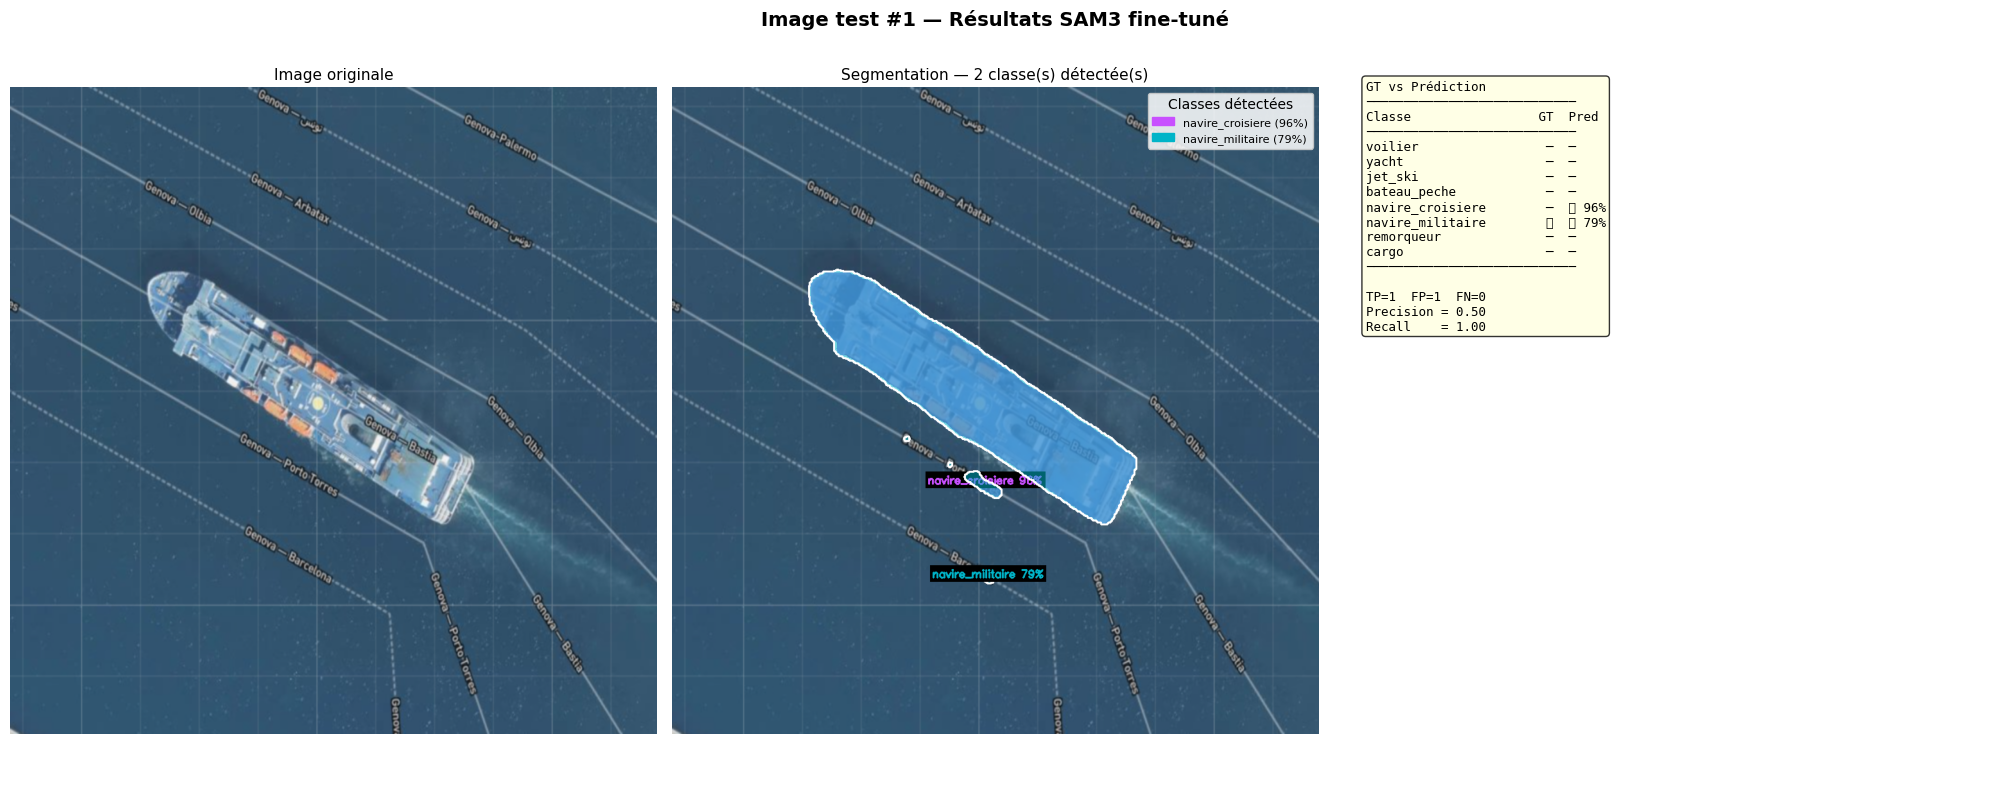

  Sauvegardé : visu_test_image_1.png

Image 2 — Classes GT présentes : ['cargo']
           Classes prédites   : ['cargo']


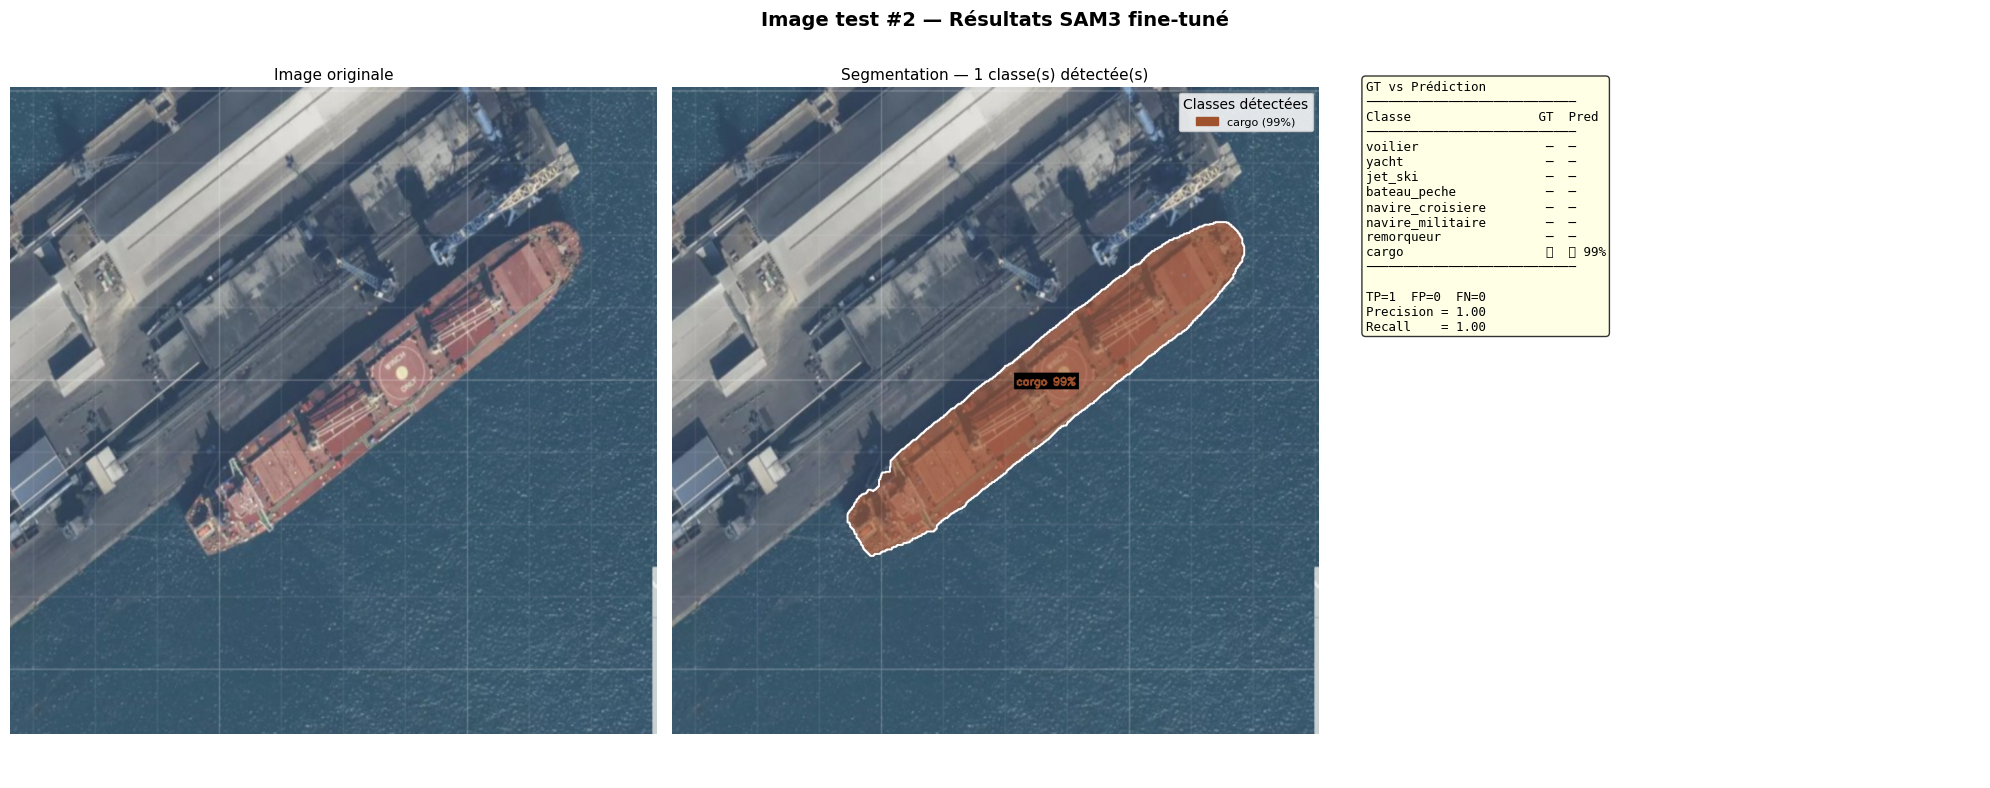

  Sauvegardé : visu_test_image_2.png

✅ Terminé !


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# VISUALISATION — Segmentation + Classification sur images test
# Prend 2 images du test_loader et affiche les résultats du modèle fine-tuné
# ════════════════════════════════════════════════════════════════════════════

import os, glob, torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from ultralytics.models.sam import SAM3SemanticPredictor
from ultralytics.models.sam.sam3.geometry_encoders import Prompt

os.chdir("/home/jupyter-p2m")
DEVICE         = 'cuda'
CHECKPOINT_DIR = '/home/jupyter-p2m/checkpoints2'
BEST_MODEL     = f'{CHECKPOINT_DIR}/sam3_semantic_best.pt'
SEUIL_PRESENCE = 0.5
NC             = len(CLASS_NAMES)

COULEURS = [
    (255,  80,  80),   # voilier        rouge
    ( 80, 180, 255),   # yacht          bleu clair
    ( 80, 255,  80),   # jet_ski        vert
    (255, 200,   0),   # bateau_peche   jaune
    (200,  80, 255),   # navire_croisiere violet
    (  0, 180, 200),   # navire_militaire cyan
    (255, 140,   0),   # remorqueur     orange
    (160,  82,  45),   # cargo          marron
]


# ════════════════════════════════════════════════════════════════════════════
# CHARGEMENT MODÈLE
# ════════════════════════════════════════════════════════════════════════════

overrides = dict(conf=0.25, task="segment", mode="predict",
                 model="/home/jupyter-p2m/sam3.pt",
                 save=False, imgsz=1008, half=True)
predictor = SAM3SemanticPredictor(overrides=overrides)
dummy_img  = next(glob.iglob(f'{DATASET_DIR}/train/**/*.png', recursive=True))
predictor.set_image(dummy_img)
sam = predictor.model.to(DEVICE)

if os.path.exists(BEST_MODEL):
    sam.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))
    print(f"✅ Modèle fine-tuné chargé")
else:
    print("⚠️  Modèle de base (pas de fine-tuning trouvé)")

sam.set_classes(text=PROMPTS_CLASSES)
sam.eval()


def detach_features(feats):
    out = {}
    for k, v in feats.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.detach().requires_grad_(False)
        elif isinstance(v, list):
            out[k] = [vi.detach().requires_grad_(False)
                      if isinstance(vi, torch.Tensor) else vi for vi in v]
        else:
            out[k] = v
    return out


# ════════════════════════════════════════════════════════════════════════════
# INFÉRENCE SUR 1 IMAGE
# ════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def inferer_image(sam, img_tensor):
    """
    img_tensor : float32 [1, 3, 1008, 1008] (depuis le dataloader)
    Retourne   : liste de dicts {classe, confiance, masque [1008,1008]}
    """
    with torch.amp.autocast('cuda'):
        img_fp16      = img_tensor.half()
        full_features = sam.backbone(img_fp16, captions=PROMPTS_CLASSES)
        del img_fp16

    feats = detach_features(full_features)
    del full_features
    torch.cuda.empty_cache()

    detections = []

    for c in range(NC):
        torch.cuda.empty_cache()
        try:
            geo = Prompt(
                box_embeddings=torch.zeros(0, 1, 4, device=DEVICE),
                box_mask=torch.zeros(1, 0, device=DEVICE, dtype=torch.bool),
            )
            with torch.amp.autocast('cuda'):
                out_c = sam.forward_grounding(
                    backbone_out=feats,
                    text_ids=torch.tensor([c], device=DEVICE, dtype=torch.long),
                    geometric_prompt=geo,
                )

            pres_score = torch.sigmoid(
                out_c['presence_logit_dec'][0, 0]
            ).item()

            if pres_score > SEUIL_PRESENCE:
                pred_m = out_c['pred_masks']   # [1, 200, H, H]
                H      = pred_m.shape[-1]

                # Meilleure query
                p_bin  = (torch.sigmoid(pred_m[0]) > 0.5).float()
                scores = p_bin.sum(dim=(-2, -1))   # proxy : query la plus active
                best_q = scores.argmax()

                # Masque binaire redimensionné à 1008×1008
                best_mask = torch.sigmoid(pred_m[0, best_q])   # [H, H]
                best_mask = F.interpolate(
                    best_mask.unsqueeze(0).unsqueeze(0),
                    size=(1008, 1008), mode='bilinear',
                    align_corners=False
                ).squeeze().cpu().numpy()

                detections.append({
                    'classe'   : CLASS_NAMES[c],
                    'idx'      : c,
                    'confiance': pres_score,
                    'masque'   : (best_mask > 0.5).astype(np.uint8),
                })

            del out_c
            torch.cuda.empty_cache()

        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()

    del feats
    torch.cuda.empty_cache()
    return detections


# ════════════════════════════════════════════════════════════════════════════
# VISUALISATION
# ════════════════════════════════════════════════════════════════════════════

def denormaliser(img_tensor):
    """Inverse la normalisation ImageNet → image RGB [0,255]."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.cpu().numpy().transpose(1, 2, 0)   # [H,W,3]
    img  = img * std + mean
    img  = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img


def dessiner_segmentation(image_rgb, detections):
    """
    Superpose les masques colorés + contours + labels sur l'image.
    Retourne l'image annotée et les patches de légende.
    """
    canvas  = image_rgb.copy().astype(np.float32)
    patches = []

    for det in detections:
        c        = det['idx']
        couleur  = COULEURS[c]
        masque   = det['masque']   # [1008,1008] binaire

        # Colorier les pixels du masque (blend 50%)
        for ch, val in enumerate(couleur):
            canvas[:, :, ch] = np.where(
                masque == 1,
                canvas[:, :, ch] * 0.45 + val * 0.55,
                canvas[:, :, ch]
            )

        canvas_u8   = canvas.astype(np.uint8)
        contours, _ = cv2.findContours(masque, cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(canvas_u8, contours, -1, (255, 255, 255), 2)

        # Label avec confiance
        if contours:
            M   = cv2.moments(contours[0])
            if M['m00'] > 0:
                cx = int(M['m10'] / M['m00'])
                cy = int(M['m01'] / M['m00'])
            else:
                x, y, w, h = cv2.boundingRect(contours[0])
                cx, cy = x + w//2, y + h//2

            label = f"{det['classe']} {det['confiance']:.0%}"
            font  = cv2.FONT_HERSHEY_SIMPLEX
            (tw, th), _ = cv2.getTextSize(label, font, 0.55, 2)
            cv2.rectangle(canvas_u8,
                          (cx - tw//2 - 3, cy - th - 8),
                          (cx + tw//2 + 3, cy + 4),
                          (0, 0, 0), -1)
            cv2.putText(canvas_u8, label,
                        (cx - tw//2, cy - 2),
                        font, 0.55, couleur, 2)

        canvas = canvas_u8.astype(np.float32)
        patches.append(mpatches.Patch(
            color=[v/255 for v in couleur],
            label=f"{det['classe']} ({det['confiance']:.0%})"
        ))

    return canvas.astype(np.uint8), patches


def afficher_resultats(img_tensor, gt_presence, detections, idx_image):
    """
    Affiche côte à côte :
      1. Image originale
      2. Image segmentée par le modèle
      3. Comparaison GT vs Prédit (tableau textuel)
    """
    image_rgb     = denormaliser(img_tensor[0])
    image_annotee, patches = dessiner_segmentation(image_rgb, detections)

    fig = plt.figure(figsize=(20, 8))
    fig.suptitle(f'Image test #{idx_image} — Résultats SAM3 fine-tuné',
                 fontsize=14, fontweight='bold')

    # ── Original ──────────────────────────────────────────────────────
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(image_rgb)
    ax1.set_title('Image originale', fontsize=11)
    ax1.axis('off')

    # ── Segmenté ──────────────────────────────────────────────────────
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(image_annotee)
    ax2.set_title(f'Segmentation — {len(detections)} classe(s) détectée(s)',
                  fontsize=11)
    if patches:
        ax2.legend(handles=patches, loc='upper right',
                   fontsize=8, framealpha=0.85,
                   title='Classes détectées')
    ax2.axis('off')

    # ── Comparaison GT vs Prédit ───────────────────────────────────────
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.axis('off')

    gt_classes   = [CLASS_NAMES[i] for i in range(NC)
                    if gt_presence[0, i].item() > 0.5]
    pred_classes = [d['classe'] for d in detections]

    lines   = ['GT vs Prédiction\n' + '─'*28]
    lines.append(f"{'Classe':<20} {'GT':>4} {'Pred':>5}")
    lines.append('─' * 28)

    for i, cls in enumerate(CLASS_NAMES):
        gt_p   = '✅' if gt_presence[0, i].item() > 0.5 else '─'
        pred_p = next(
            (f"✅ {d['confiance']:.0%}" for d in detections
             if d['idx'] == i), '─'
        )
        lines.append(f"{cls:<20} {gt_p:>4}  {pred_p}")

    lines.append('─' * 28)
    tp = sum(1 for d in detections
             if gt_presence[0, d['idx']].item() > 0.5)
    fp = sum(1 for d in detections
             if gt_presence[0, d['idx']].item() <= 0.5)
    fn = sum(1 for i in range(NC)
             if gt_presence[0, i].item() > 0.5
             and i not in [d['idx'] for d in detections])

    lines.append(f"\nTP={tp}  FP={fp}  FN={fn}")
    lines.append(f"Precision = {tp/(tp+fp+1e-9):.2f}")
    lines.append(f"Recall    = {tp/(tp+fn+1e-9):.2f}")

    ax3.text(0.05, 0.95, '\n'.join(lines),
             transform=ax3.transAxes,
             fontsize=9, verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow',
                       alpha=0.8))

    plt.tight_layout()
    plt.savefig(
        f'/home/jupyter-p2m/evaluation/visu_test_image_{idx_image}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"  Sauvegardé : visu_test_image_{idx_image}.png")


# ════════════════════════════════════════════════════════════════════════════
# LANCEMENT — 2 images du test_loader
# ════════════════════════════════════════════════════════════════════════════

os.makedirs('/home/jupyter-p2m/evaluation', exist_ok=True)

print("\n🔍 Inférence sur 2 images du test set...\n")

for idx, batch in enumerate(test_loader):
    if idx >= 2:
        break

    img      = batch['image'].to(DEVICE)      # [1,3,1008,1008]
    gt_masks = batch['gt_masks'].to(DEVICE)   # [1,8,288,288]
    presence = batch['presence'].to(DEVICE)   # [1,8]

    gt_classes = [CLASS_NAMES[i] for i in range(NC)
                  if presence[0, i].item() > 0.5]
    print(f"Image {idx+1} — Classes GT présentes : {gt_classes}")

    detections = inferer_image(sam, img[0].unsqueeze(0))
    pred_cls   = [d['classe'] for d in detections]
    print(f"           Classes prédites   : {pred_cls}")

    afficher_resultats(img, presence, detections, idx_image=idx+1)
    print()

print("✅ Terminé !")

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# RÉÉQUILIBRAGE AUTOMATIQUE DES BATCHS
#
# 1. Mesure la distribution actuelle (instances par classe par batch)
# 2. Calcule les déplacements optimaux pour atteindre Train≈70% Val≈15% Test≈15%
# 3. Affiche le plan de déplacement
# 4. Exécute les déplacements après confirmation
#
# Contraintes :
#   - On déplace des BATCHS ENTIERS (20 images)
#   - On ne fractionne pas les batchs
#   - Priorité : rééquilibrer voilier (critique : val=1%, test=22%)
#                et remorqueur (val=21%, test=19% → trop dans val/test)
# ════════════════════════════════════════════════════════════════════════════

import os, glob, shutil
import xml.etree.ElementTree as ET
import numpy as np

DATASET_DIR = '/home/jupyter-p2m/dataset'
CLASS_NAMES = [
    'voilier', 'yacht', 'jet_ski', 'bateau_peche',
    'navire_croisiere', 'navire_militaire', 'remorqueur', 'cargo'
]
ABREV  = ['voil', 'yacht', 'j_ski', 'b_pec', 'crois', 'milit', 'remor', 'cargo']
NC     = len(CLASS_NAMES)
SPLITS = ['train', 'val', 'test']

# Objectifs (% de chaque classe dans train/val/test)
OBJECTIF = {'train': 0.70, 'val': 0.15, 'test': 0.15}


# ════════════════════════════════════════════════════════════════════════════
# ÉTAPE 1 — MESURE
# ════════════════════════════════════════════════════════════════════════════

def compter_instances_batch(batch_dir):
    xmls = (glob.glob(os.path.join(batch_dir, '*_cvat.xml')) +
            glob.glob(os.path.join(batch_dir, '*_sam3.xml')))
    inst = np.zeros(NC, dtype=np.int64)
    n    = 0
    if xmls:
        try:
            root = ET.parse(xmls[0]).getroot()
            for img in root.findall('.//image'):
                if os.path.exists(os.path.join(batch_dir, img.get('name',''))):
                    n += 1
                    for poly in img.findall('polygon'):
                        lbl = poly.get('label','')
                        if lbl in CLASS_NAMES:
                            inst[CLASS_NAMES.index(lbl)] += 1
        except:
            pass
    else:
        exts = ('.jpg','.jpeg','.png','.bmp','.tiff')
        n = len([f for f in os.listdir(batch_dir)
                 if f.lower().endswith(exts)])
    return inst, n


def mesurer_tout():
    """Retourne dict : {split: [{nom, path, inst[NC], n_images}]}"""
    data = {}
    for split in SPLITS:
        split_dir  = os.path.join(DATASET_DIR, split)
        batch_dirs = sorted([
            d for d in glob.glob(os.path.join(split_dir, 'batch*'))
            if os.path.isdir(d)
        ])
        batchs = []
        for bd in batch_dirs:
            inst, n = compter_instances_batch(bd)
            batchs.append({
                'nom'   : os.path.basename(bd),
                'path'  : bd,
                'inst'  : inst,
                'n_img' : n,
            })
        data[split] = batchs
    return data


# ════════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 — AFFICHAGE
# ════════════════════════════════════════════════════════════════════════════

def afficher_distribution(data):
    col = 6
    sep = '  '
    hdr = sep.join(f'{a:>{col}}' for a in ABREV)

    for split in SPLITS:
        batchs     = data[split]
        total_inst = sum(b['inst'] for b in batchs)
        total_img  = sum(b['n_img'] for b in batchs)

        line = f"  {'─'*(14+8+2+NC*8)}"
        print(f"\n{'═'*(14+8+2+NC*8+10)}")
        print(f"  {split.upper()}  —  {len(batchs)} batchs  —  {total_img} images")
        print(f"{'═'*(14+8+2+NC*8+10)}")
        print(f"  {'Batch':<12} {'Imgs':>4}  |  {hdr}  |  Total")
        print(line)
        for b in batchs:
            vals = sep.join(f'{b["inst"][c]:>{col}}' for c in range(NC))
            print(f"  {b['nom']:<12} {b['n_img']:>4}  |  {vals}  |  {b['inst'].sum():>6}")
        print(line)
        tot = sep.join(f'{total_inst[c]:>{col}}' for c in range(NC))
        print(f"  {'TOTAL':<12} {total_img:>4}  |  {tot}  |  {total_inst.sum():>6}")

    # Résumé global
    totaux = {s: sum(b['inst'] for b in data[s]) for s in SPLITS}
    global_total = sum(totaux[s] for s in SPLITS)

    print(f"\n{'═'*75}")
    print(f"  DISTRIBUTION ACTUELLE")
    print(f"{'═'*75}")
    print(f"  {'Classe':<20} {'Train':>8} {'Val':>8} {'Test':>8} "
          f"{'Total':>8}  |  {'%Tr':>5} {'%Va':>5} {'%Te':>5}  | Écart obj")
    print(f"  {'─'*73}")

    for c, cls in enumerate(CLASS_NAMES):
        tr  = int(totaux['train'][c])
        vl  = int(totaux['val'][c])
        te  = int(totaux['test'][c])
        tot = tr + vl + te
        if tot == 0:
            continue
        ptr = tr/tot; pvl = vl/tot; pte = te/tot
        ecart = max(abs(ptr-0.70), abs(pvl-0.15), abs(pte-0.15))
        flag  = ' ⚠️ ' if ecart > 0.10 else '   '
        print(f"  {cls:<20} {tr:>8} {vl:>8} {te:>8} {tot:>8}  |  "
              f"{100*ptr:>4.0f}% {100*pvl:>4.0f}% {100*pte:>4.0f}%  |"
              f"  {ecart*100:>4.1f}%{flag}")

    print(f"{'═'*75}")
    return totaux, global_total


# ════════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 — OPTIMISATION DES DÉPLACEMENTS
#
# Algorithme glouton :
#   Pour chaque classe déséquilibrée :
#     Si val ou test ont trop d'instances → chercher batchs à déplacer vers train
#     Si train a trop peu → idem
#   On trie les batchs source par "gain" (instances de la classe cible)
#   On déplace jusqu'à atteindre l'objectif ou épuiser les candidats
# ════════════════════════════════════════════════════════════════════════════

def calculer_plan(data, totaux, global_total):
    """
    Calcule les déplacements et duplications nécessaires.
    Retourne (mouvements, batchs_apres).
    Un mouvement peut être :
      - type='move'      : déplacement batch de src → dst
      - type='duplicate' : copie batch de src → dst (batch reste dans src)
    """
    # Copie mutable
    batchs = {s: list(data[s]) for s in SPLITS}
    mouvements = []
    # Noms de batchs déjà dupliqués (pour éviter doublons infinis)
    deja_dupliques = set()

    def totaux_courants():
        result = {}
        for s in SPLITS:
            if batchs[s]:
                result[s] = np.sum([b['inst'] for b in batchs[s]], axis=0)
            else:
                result[s] = np.zeros(NC, dtype=np.int64)
        return result

    def total_global():
        t = totaux_courants()
        return int(sum(t[s].sum() for s in SPLITS))

    def desequilibres():
        """
        Retourne liste de (classe, src_surplus, dst_deficit, ecart)
        triée par écart décroissant.
        """
        t    = totaux_courants()
        res  = []
        for c, cls in enumerate(CLASS_NAMES):
            tot = sum(int(t[s][c]) for s in SPLITS)
            if tot == 0:
                continue
            ratios = {s: float(t[s][c]) / tot for s in SPLITS}
            for src in SPLITS:
                if ratios[src] <= OBJECTIF[src] + 0.05:
                    continue
                for dst in SPLITS:
                    if dst == src:
                        continue
                    if ratios[dst] >= OBJECTIF[dst] - 0.05:
                        continue
                    ecart = ratios[src] - OBJECTIF[src]
                    res.append((c, cls, src, dst, ecart, ratios))
        res.sort(key=lambda x: -x[4])
        return res

    MAX_ITER = 80
    for iteration in range(MAX_ITER):
        desq = desequilibres()
        if not desq:
            break

        any_move = False

        for c, cls, src, dst, ecart, ratios in desq:
            t = totaux_courants()

            # ── Essayer un DÉPLACEMENT ────────────────────────────────
            candidats = sorted(
                batchs[src],
                key=lambda b: int(b['inst'][c]),
                reverse=True
            )
            moved = False
            for candidat in candidats:
                if int(candidat['inst'][c]) == 0:
                    break

                t_sim = {s: t[s].copy() for s in SPLITS}
                t_sim[src] = t_sim[src] - candidat['inst']
                t_sim[dst] = t_sim[dst] + candidat['inst']

                tot_c = sum(int(t_sim[s][c]) for s in SPLITS)
                if tot_c == 0:
                    continue

                ecart_avant = abs(float(t[src][c]) / tot_c - OBJECTIF[src])
                ecart_apres = abs(float(t_sim[src][c]) / tot_c - OBJECTIF[src])

                # Vérifier que le déplacement n'empire aucune autre classe
                casse_autre = False
                for c2 in range(NC):
                    if c2 == c:
                        continue
                    tot_c2 = sum(int(t_sim[s][c2]) for s in SPLITS)
                    if tot_c2 == 0:
                        continue
                    r_src = float(t_sim[src][c2]) / tot_c2
                    r_dst = float(t_sim[dst][c2]) / tot_c2
                    # Pénaliser si on crée un déséquilibre > 15% sur une autre classe
                    if (abs(r_src - OBJECTIF[src]) > 0.15 or
                            abs(r_dst - OBJECTIF[dst]) > 0.15):
                        casse_autre = True
                        break

                if ecart_apres < ecart_avant and not casse_autre:
                    batchs[src].remove(candidat)
                    batchs[dst].append(candidat)
                    mouvements.append({
                        'type'  : 'move',
                        'batch' : candidat['nom'],
                        'de'    : src,
                        'vers'  : dst,
                        'inst'  : candidat['inst'].copy(),
                        'raison': cls,
                    })
                    any_move = True
                    moved    = True
                    break

            if moved:
                break   # recalculer les déséquilibres

            # ── Si déplacement impossible → essayer DUPLICATION ───────
            # Dupliquer = copier le batch dans dst SANS le retirer de src
            # Utile quand src ne peut pas perdre ce batch (déséquilibrerait
            # une autre classe) mais dst en a besoin
            for candidat in candidats:
                if int(candidat['inst'][c]) == 0:
                    break
                cle_dup = f"{candidat['nom']}→{dst}"
                if cle_dup in deja_dupliques:
                    continue
                # Vérifier que la duplication aide
                t_sim = {s: t[s].copy() for s in SPLITS}
                t_sim[dst] = t_sim[dst] + candidat['inst']
                tot_c = sum(int(t_sim[s][c]) for s in SPLITS)
                if tot_c == 0:
                    continue
                ratio_dst_apres = float(t_sim[dst][c]) / tot_c
                if abs(ratio_dst_apres - OBJECTIF[dst]) < abs(ratios[dst] - OBJECTIF[dst]):
                    # Dupliquer : ajouter une copie dans dst
                    copie = {
                        'nom'   : candidat['nom'] + '_dup',
                        'path'  : candidat['path'],
                        'inst'  : candidat['inst'].copy(),
                        'n_img' : candidat['n_img'],
                    }
                    batchs[dst].append(copie)
                    deja_dupliques.add(cle_dup)
                    mouvements.append({
                        'type'  : 'duplicate',
                        'batch' : candidat['nom'],
                        'de'    : src,
                        'vers'  : dst,
                        'inst'  : candidat['inst'].copy(),
                        'raison': cls,
                    })
                    any_move = True
                    break

            if any_move:
                break

        if not any_move:
            break

    return mouvements, batchs


# ════════════════════════════════════════════════════════════════════════════
# ÉTAPE 4 — AFFICHAGE DU PLAN
# ════════════════════════════════════════════════════════════════════════════

def afficher_plan(mouvements, batchs_apres):
    if not mouvements:
        print("\n✅ Distribution déjà équilibrée — aucun déplacement nécessaire")
        return

    moves = [m for m in mouvements if m['type'] == 'move']
    dups  = [m for m in mouvements if m['type'] == 'duplicate']

    print(f"\n{'═'*85}")
    print(f"  PLAN  —  {len(moves)} déplacement(s)  +  {len(dups)} duplication(s)")
    print(f"{'═'*85}")
    print(f"  {'Type':<5} {'Batch':<16} {'De':>6} → {'Vers':<6}  │  "
          + '  '.join(f'{a:>5}' for a in ABREV) + '  │  Raison')
    print(f"  {'─'*83}")

    for m in mouvements:
        vals  = '  '.join(f'{m["inst"][c]:>5}' for c in range(NC))
        typ   = 'MOV' if m['type'] == 'move' else 'DUP'
        print(f"  {typ:<5} {m['batch']:<16} {m['de']:>6} → {m['vers']:<6}  │  "
              f"{vals}  │  {m['raison']}")

    if dups:
        print(f"\n  DUP = duplication : le batch est COPIÉ dans la destination")
        print(f"        (reste aussi dans la source)")

    # Distribution après
    totaux_apres = {s: sum(b['inst'] for b in batchs_apres[s]) for s in SPLITS}
    global_apres = sum(totaux_apres[s] for s in SPLITS)

    print(f"\n{'═'*75}")
    print(f"  DISTRIBUTION APRÈS DÉPLACEMENT")
    print(f"{'═'*75}")
    print(f"  {'Classe':<20} {'Train':>8} {'Val':>8} {'Test':>8}  |  "
          f"{'%Tr':>5} {'%Va':>5} {'%Te':>5}")
    print(f"  {'─'*73}")
    for c, cls in enumerate(CLASS_NAMES):
        tr  = int(totaux_apres['train'][c])
        vl  = int(totaux_apres['val'][c])
        te  = int(totaux_apres['test'][c])
        tot = tr + vl + te
        if tot == 0:
            continue
        print(f"  {cls:<20} {tr:>8} {vl:>8} {te:>8}  |  "
              f"{100*tr/tot:>4.0f}% {100*vl/tot:>4.0f}% {100*te/tot:>4.0f}%")

    n_train = sum(b['n_img'] for b in batchs_apres['train'])
    n_val   = sum(b['n_img'] for b in batchs_apres['val'])
    n_test  = sum(b['n_img'] for b in batchs_apres['test'])
    print(f"\n  Images : train={n_train} | val={n_val} | test={n_test}")
    print(f"{'═'*75}")


# ════════════════════════════════════════════════════════════════════════════
# ÉTAPE 5 — EXÉCUTION DES DÉPLACEMENTS
# ════════════════════════════════════════════════════════════════════════════

def executer_deplacements(mouvements):
    if not mouvements:
        return

    print(f"\n{'═'*55}")
    print(f"  EXÉCUTION")
    print(f"{'═'*55}")

    for m in mouvements:
        # Nom réel du batch (sans suffixe _dup)
        nom_reel = m['batch'].replace('_dup', '')
        src_dir  = os.path.join(DATASET_DIR, m['de'],   nom_reel)
        dst_dir  = os.path.join(DATASET_DIR, m['vers'], nom_reel)

        if not os.path.exists(src_dir):
            print(f"  ⚠️  {nom_reel} : source introuvable")
            continue

        if m['type'] == 'move':
            if os.path.exists(dst_dir):
                print(f"  ⚠️  {nom_reel} : destination existe déjà — ignoré")
                continue
            try:
                shutil.move(src_dir, dst_dir)
                print(f"  ✅ MOV {nom_reel:<14} {m['de']} → {m['vers']}")
            except Exception as e:
                print(f"  ❌ {nom_reel} : {e}")

        elif m['type'] == 'duplicate':
            if os.path.exists(dst_dir):
                print(f"  ⚠️  {nom_reel} : copie déjà présente dans {m['vers']} — ignoré")
                continue
            try:
                shutil.copytree(src_dir, dst_dir)
                print(f"  ✅ DUP {nom_reel:<14} {m['de']} → {m['vers']} (copie)")
            except Exception as e:
                print(f"  ❌ {nom_reel} (dup) : {e}")

    print(f"\n  Terminé !")
    print(f"  → Relancez le dataloader pour prendre en compte les changements")


# ════════════════════════════════════════════════════════════════════════════
# PIPELINE PRINCIPAL
# ════════════════════════════════════════════════════════════════════════════

# ── 1. Mesurer ────────────────────────────────────────────────────────
print("⏳ Mesure de la distribution actuelle...")
data = mesurer_tout()

# ── 2. Afficher la distribution actuelle ─────────────────────────────
totaux, global_total = afficher_distribution(data)

# ── 3. Calculer le plan ───────────────────────────────────────────────
print("\n⏳ Calcul du plan de rééquilibrage...")
mouvements, batchs_apres = calculer_plan(data, totaux, global_total)

# ── 4. Afficher le plan ───────────────────────────────────────────────
afficher_plan(mouvements, batchs_apres)

# ── 5. Demander confirmation et exécuter ─────────────────────────────
if mouvements:
    print(f"\n  ⚠️  {len(mouvements)} batch(s) vont être déplacés sur le disque.")
    print(f"  Cette opération est IRRÉVERSIBLE (sans sauvegarde manuelle).")
    reponse = input("\n  Confirmer le déplacement ? (oui/non) : ").strip().lower()

    if reponse == 'oui':
        executer_deplacements(mouvements)

        # Vérification finale
        print("\n⏳ Vérification après déplacement...")
        data_apres = mesurer_tout()
        afficher_distribution(data_apres)
    else:
        print("\n  Annulé — aucun fichier déplacé.")
        print("  Le plan ci-dessus est disponible pour déplacement manuel.")

⏳ Mesure de la distribution actuelle...

══════════════════════════════════════════════════════════════════════════════════════════════════
  TRAIN  —  45 batchs  —  900 images
══════════════════════════════════════════════════════════════════════════════════════════════════
  Batch        Imgs  |    voil   yacht   j_ski   b_pec   crois   milit   remor   cargo  |  Total
  ────────────────────────────────────────────────────────────────────────────────────────
  batch1         20  |      73     188       0       3      13      10       8      28  |     323
  batch10        20  |      37     143       0     126      13      14      12      37  |     382
  batch10a       20  |       0      83      34     158      20      14      33      61  |     403
  batch11        20  |      21     168       0      89       3      24      17      36  |     358
  batch11a       20  |       0      33      53     123      16       7      47      35  |     314
  batch12        20  |      24     235       0